## 1. Notebook Setup

This notebook uses unsupervised learning to identify distinct climate-housing vulnerability profiles across Florida county-years.

Clusters are created using vulnerability sub-scores. Housing-market indicators are used afterwards to interpret the profiles and identify possible hidden-risk counties.

In [1]:
# ==================================================
# Imports
# ==================================================

from pathlib import Path
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# Clustering Tools
# ==================================================

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

from sklearn.decomposition import PCA

# ==================================================
# Project Paths
# ==================================================

PROJECT_ROOT = Path("..")

INTERIM_DATA = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "county_year_features"
)

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "vulnerability_clustering"
)

RESULTS_FIGURES = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "vulnerability_clustering"
)

RESULTS_LOGS = (
    PROJECT_ROOT
    / "results"
    / "logs"
)

RESULTS_MODELS = (
    PROJECT_ROOT
    / "results"
    / "models"
    / "vulnerability_clustering"
)

# ==================================================
# Input Dataset
# ==================================================

INPUT_DATA_PATH = (
    INTERIM_DATA
    / "county_year_vulnerability_scores.csv"
)

# ==================================================
# Output Folders
# ==================================================

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS_LOGS.mkdir(parents=True, exist_ok=True)
RESULTS_MODELS.mkdir(parents=True, exist_ok=True)

# ==================================================
# Project Settings
# ==================================================

PROJECT_START_YEAR = 2011
PROJECT_END_YEAR = 2025

RANDOM_STATE = 42

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Notebook setup complete.")
print(f"Input dataset: {INPUT_DATA_PATH}")
print(f"Results tables folder: {RESULTS_TABLES}")
print(f"Results figures folder: {RESULTS_FIGURES}")

Notebook setup complete.
Input dataset: ..\data\interim\county_year_features\county_year_vulnerability_scores.csv
Results tables folder: ..\results\tables\vulnerability_clustering
Results figures folder: ..\results\figures\vulnerability_clustering


## 2. Load Vulnerability-Ready Dataset

Load the county-year vulnerability dataset and verify its shape, year range, county coverage, and required clustering variables.

In [2]:
# ==================================================
# Step 2: Load Vulnerability-Ready Dataset
# ==================================================

county_year_data = pd.read_csv(INPUT_DATA_PATH)

print("Vulnerability-ready dataset loaded successfully.")
print(f"Dataset shape: {county_year_data.shape}")

display(county_year_data.head())

Vulnerability-ready dataset loaded successfully.
Dataset shape: (1000, 123)


,STCOFIPS,RegionID,RegionName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,COUNTY,Year,avg_annual_housing_price,median_annual_housing_price,min_annual_housing_price,max_annual_housing_price,annual_price_volatility,monthly_observations,is_metro,SizeRank,POPULATION,CFLD_RISKS,HRCN_RISKS,SOVI_SCORE,RESL_SCORE,prev_year_housing_price,annual_price_growth_dollar,annual_price_growth_pct,baseline_housing_price,appreciation_from_baseline_pct,price_growth_acceleration,high_growth_flag,high_volatility_flag,complete_year_flag,neighbor_count,neighbor_avg_housing_price,neighbor_avg_price_growth_pct,neighbor_avg_price_volatility,neighbor_high_growth_share,neighbor_high_volatility_share,disaster_count,unique_disaster_events,climate_disaster_count,hurricane_disaster_count,tropical_storm_disaster_count,severe_storm_disaster_count,flood_disaster_count,fire_disaster_count,any_disaster_flag,any_climate_disaster_flag,cumulative_disaster_count,cumulative_climate_disaster_count,recent_3yr_disaster_count,recent_3yr_climate_disaster_count,acs_total_population,median_household_income,poverty_rate,unemployment_rate,owner_occupied_share,renter_occupied_share,median_gross_rent,acs_median_home_value,price_to_income_ratio,acs_estimated_2025_flag,nfip_claim_count,nfip_policy_count_sum,nfip_total_building_payment,nfip_total_contents_payment,nfip_total_icc_payment,nfip_total_claim_payment,nfip_avg_claim_payment,nfip_total_building_coverage,nfip_total_contents_coverage,nfip_cumulative_claim_count,nfip_cumulative_claim_payment,nfip_recent_3yr_claim_count,nfip_recent_3yr_claim_payment,nfip_claim_year_indicator,log_annual_price_volatility,log_price_to_income_ratio,log_median_gross_rent,log_neighbor_avg_price_volatility,log_nfip_claim_count,log_nfip_total_claim_payment,log_nfip_cumulative_claim_payment,log_nfip_recent_3yr_claim_payment,log_nfip_avg_claim_payment,scaled_annual_price_growth_pct,scaled_appreciation_from_baseline_pct,scaled_log_annual_price_volatility,scaled_price_growth_acceleration,scaled_log_price_to_income_ratio,scaled_log_median_gross_rent,scaled_median_household_income,scaled_CFLD_RISKS,scaled_HRCN_RISKS,scaled_climate_disaster_count,scaled_cumulative_climate_disaster_count,scaled_recent_3yr_climate_disaster_count,scaled_hurricane_disaster_count,scaled_SOVI_SCORE,scaled_poverty_rate,scaled_unemployment_rate,scaled_renter_occupied_share,scaled_RESL_SCORE,scaled_log_nfip_claim_count,scaled_log_nfip_total_claim_payment,scaled_log_nfip_cumulative_claim_payment,scaled_log_nfip_recent_3yr_claim_payment,scaled_log_nfip_avg_claim_payment,scaled_neighbor_avg_price_growth_pct,scaled_log_neighbor_avg_price_volatility,scaled_neighbor_high_growth_share,scaled_neighbor_high_volatility_share,scaled_low_income_stress,scaled_low_resilience,housing_pressure_score,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score,climate_housing_vulnerability_score,vulnerability_class
0,12001,1509,Alachua County,FL,"Gainesville, FL",12,1,Alachua,2011,"144,811.6070","144,342.9672","140,135.5499","151,065.3041","4,024.2825",12,1,251,277984,0.0000,96.7042,34.7646,80.9796,"162,126.8332","-17,315.2262",-10.6800,"162,126.8332",-10.6800,0.0000,0.0000,1,1,7,"102,374.8496",-6.7638,"1,794.8931",0.0000,0.1429,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"246,203.0000","41,373.0000",23.5571,7.3324,54.4678,45.5322,880.0000,"185,100.0000",3.5001,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,8.3004,1.5041,6.7811,7.4933,0.0000,0.0000,0.0000,0.0000,0.0000,0.0672,0.0310,0.5461,0.6198,0.3030,0.3665,0.1303,0.0000,0.8723,0.0000,0.0000,0.0000,0.0000,0.2702,0.6838,0.2453,0.9157,0.8400,0.0000,0.0000,0.0000,0.0000,0.0000,0.1196,0.2833,0.0000,0.1429,0.8697,0.1600,0.3160,0.5131,0.4362,0.0000,0.5287,0.1600,0.0000,0.1364,0.2613,Low
1,12001,1509,Alachua County,FL,"Gainesville, FL",12,1,Alachua,2012,"136,832.4264","136,443.4221","134,664.5101","139

In [3]:
# ==================================================
# Step 2.1: Validate Dataset Coverage
# ==================================================

CLUSTERING_FEATURES = [
    "affordability_stress_score",
    "climate_exposure_score",
    "disaster_history_score",
    "socioeconomic_vulnerability_score",
    "resilience_adjustment_score",
    "insurance_loss_stress_score",
    "spatial_spillover_score"
]

required_columns = [
    "STCOFIPS",
    "RegionName",
    "Year",
    "vulnerability_class",
    "climate_housing_vulnerability_score"
] + CLUSTERING_FEATURES

missing_columns = [
    column for column in required_columns
    if column not in county_year_data.columns
]

print("Dataset validation summary")
print("-" * 40)
print(f"Rows: {len(county_year_data):,}")
print(f"Columns: {county_year_data.shape[1]}")
print(f"Counties: {county_year_data['STCOFIPS'].nunique()}")
print(
    f"Year range: "
    f"{county_year_data['Year'].min()}–"
    f"{county_year_data['Year'].max()}"
)
print(f"Duplicate county-year rows: "
      f"{county_year_data.duplicated(['STCOFIPS', 'Year']).sum()}")
print(f"Missing required columns: {len(missing_columns)}")

if missing_columns:
    print("\nMissing columns:")
    print(missing_columns)
else:
    print("\nAll required clustering columns are available.")

Dataset validation summary
----------------------------------------
Rows: 1,000
Columns: 123
Counties: 67
Year range: 2011–2025
Duplicate county-year rows: 0
Missing required columns: 0

All required clustering columns are available.


## 3. Define Clustering Features

The primary clustering model uses seven multidimensional vulnerability sub-scores while excluding direct housing-market performance outcomes. Housing growth, price level, volatility, housing pressure, and vulnerability classes are used afterwards to interpret the resulting profiles.

In [4]:
# ==================================================
# Step 3: Define Clustering and Profiling Features
# ==================================================

CLUSTERING_FEATURES = [
    "affordability_stress_score",
    "climate_exposure_score",
    "disaster_history_score",
    "socioeconomic_vulnerability_score",
    "resilience_adjustment_score",
    "insurance_loss_stress_score",
    "spatial_spillover_score"
]

PROFILING_FEATURES = [
    "housing_pressure_score",
    "annual_price_growth_pct",
    "annual_price_volatility",
    "avg_annual_housing_price",
    "climate_housing_vulnerability_score",
    "vulnerability_class"
]

available_profiling_features = [
    column for column in PROFILING_FEATURES
    if column in county_year_data.columns
]

missing_profiling_features = [
    column for column in PROFILING_FEATURES
    if column not in county_year_data.columns
]

feature_group_summary = pd.DataFrame({
    "feature_group": [
        "Clustering features",
        "Profiling features"
    ],
    "number_of_features": [
        len(CLUSTERING_FEATURES),
        len(available_profiling_features)
    ],
    "purpose": [
        "Used to create clusters",
        "Used to interpret clusters"
    ]
})

print("Feature groups defined successfully.")
print(f"Clustering features: {len(CLUSTERING_FEATURES)}")
print(f"Available profiling features: {len(available_profiling_features)}")
print(f"Missing profiling features: {len(missing_profiling_features)}")

if missing_profiling_features:
    print("\nUnavailable profiling features:")
    print(missing_profiling_features)

display(feature_group_summary)

Feature groups defined successfully.
Clustering features: 7
Available profiling features: 6
Missing profiling features: 0


,feature_group,number_of_features,purpose
0,Clustering features,7,Used to create clusters
1,Profiling features,6,Used to interpret clusters


## 4. Prepare Clustering Data

Check the selected sub-scores for missing values, distributions, and variation before standardizing them for clustering.

In [5]:
# ==================================================
# Step 4: Prepare Clustering Data
# ==================================================

clustering_data = county_year_data[
    [
        "STCOFIPS",
        "RegionName",
        "Year"
    ] + CLUSTERING_FEATURES
].copy()

clustering_summary = clustering_data[
    CLUSTERING_FEATURES
].agg([
    "count",
    "mean",
    "std",
    "min",
    "median",
    "max"
]).T

clustering_summary["missing_values"] = (
    clustering_data[CLUSTERING_FEATURES]
    .isna()
    .sum()
)

clustering_summary["unique_values"] = (
    clustering_data[CLUSTERING_FEATURES]
    .nunique()
)

clustering_summary = clustering_summary[
    [
        "count",
        "missing_values",
        "unique_values",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ]
]

print("Clustering data preparation summary")
print("-" * 40)
print(f"Rows available: {len(clustering_data):,}")
print(
    f"Rows with missing clustering values: "
    f"{clustering_data[CLUSTERING_FEATURES].isna().any(axis=1).sum():,}"
)
print(
    f"Duplicate county-year rows: "
    f"{clustering_data.duplicated(['STCOFIPS', 'Year']).sum():,}"
)

display(clustering_summary)

Clustering data preparation summary
----------------------------------------
Rows available: 1,000
Rows with missing clustering values: 0
Duplicate county-year rows: 0


,count,missing_values,unique_values,mean,std,min,median,max
affordability_stress_score,"1,000.0000",0,1000,0.5023,0.0760,0.2947,0.4962,0.7868
climate_exposure_score,"1,000.0000",0,67,0.6221,0.2598,0.0000,0.6174,1.0000
disaster_history_score,"1,000.0000",0,201,0.2464,0.2273,0.0000,0.2195,1.0000
socioeconomic_vulnerability_score,"1,000.0000",0,1000,0.4175,0.1274,0.0558,0.4194,0.7713
resilience_adjustment_score,"1,000.0000",0,67,0.6687,0.2395,0.0000,0.6989,1.0000
insurance_loss_stress_score,"1,000.0000",0,868,0.4383,0.2366,0.0000,0.5050,0.9836
spatial_spillover_score,"1,000.0000",0,1000,0.4769,0.2519,0.0589,0.4561,0.9870


### Interpretation

All 1,000 county-year observations contain complete values for the seven clustering features, so no rows require removal or imputation.

The features show different levels of variation. Climate exposure and resilience have 67 unique values, indicating that they are largely county-level measures repeated across years. Disaster history, insurance-loss stress, affordability, socioeconomic vulnerability, and spatial spillovers vary more across county-years.

Because the feature standard deviations differ, the variables should be standardized before clustering so that no single dimension dominates the distance calculations.

## 5. Examine Feature Relationships

A correlation matrix is used to check whether the vulnerability dimensions overlap strongly before clustering.

,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score
affordability_stress_score,1.0000,0.5460,0.3610,-0.2210,-0.1890,0.5110,0.3100
climate_exposure_score,0.5460,1.0000,0.0170,-0.2140,-0.1160,0.6120,0.1330
disaster_history_score,0.3610,0.0170,1.0000,-0.3320,-0.0130,0.2810,0.1670
socioeconomic_vulnerability_score,-0.2210,-0.2140,-0.3320,1.0000,0.4410,-0.3230,-0.1420
resilience_adjustment_score,-0.1890,-0.1160,-0.0130,0.4410,1.0000,-0.2170,-0.0080
insurance_loss_stress_score,0.5110,0.6120,0.2810,-0.3230,-0.2170,1.0000,0.1850
spatial_spillover_score,0.3100,0.1330,0.1670,-0.1420,-0.0080,0.1850,1.0000


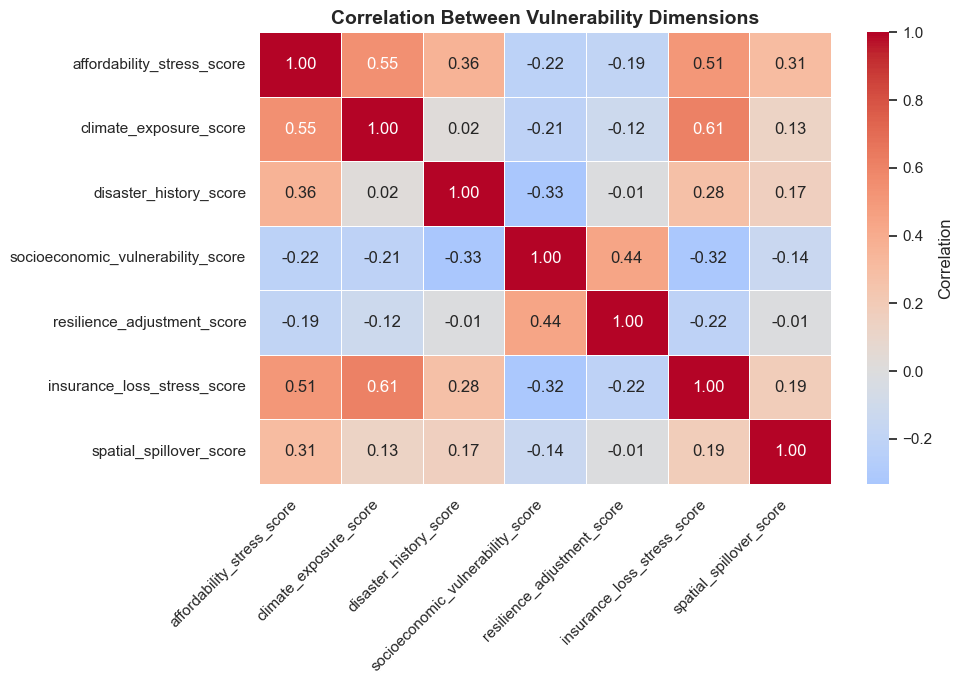

Correlation heatmap saved to: ..\results\figures\vulnerability_clustering\clustering_feature_correlation_heatmap.png


In [6]:
# ==================================================
# Step 5: Examine Feature Relationships
# ==================================================

correlation_matrix = (
    clustering_data[CLUSTERING_FEATURES]
    .corr()
)

display(correlation_matrix.round(3))

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title(
    "Correlation Between Vulnerability Dimensions",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

figure_path = (
    RESULTS_FIGURES
    / "clustering_feature_correlation_heatmap.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Correlation heatmap saved to: {figure_path}")

### Interpretation

The vulnerability dimensions show moderate but not excessive correlation, indicating that they capture related yet distinct forms of county-level stress.

Climate exposure is most strongly associated with insurance-loss stress, while disaster history has almost no relationship with static climate exposure. Socioeconomic vulnerability is negatively associated with disaster and insurance-loss burden, suggesting that social stress and realized climate losses are concentrated in different county profiles.

No correlation is high enough to justify removing a feature before clustering.

## 6. Standardize Clustering Features

Standardize the seven vulnerability dimensions so that each feature contributes equally to the clustering process.

In [7]:
# ==================================================
# Step 6: Standardize Clustering Features
# ==================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    clustering_data[CLUSTERING_FEATURES]
)

scaled_clustering_data = pd.DataFrame(
    X_scaled,
    columns=CLUSTERING_FEATURES,
    index=clustering_data.index
)

standardization_check = pd.DataFrame({
    "mean_after_scaling": scaled_clustering_data.mean(),
    "std_after_scaling": scaled_clustering_data.std(ddof=0)
})

print("Clustering features standardized successfully.")
print(f"Standardized data shape: {scaled_clustering_data.shape}")

display(standardization_check.round(4))

Clustering features standardized successfully.
Standardized data shape: (1000, 7)


,mean_after_scaling,std_after_scaling
affordability_stress_score,-0.0000,1.0000
climate_exposure_score,0.0000,1.0000
disaster_history_score,0.0000,1.0000
socioeconomic_vulnerability_score,-0.0000,1.0000
resilience_adjustment_score,0.0000,1.0000
insurance_loss_stress_score,-0.0000,1.0000
spatial_spillover_score,-0.0000,1.0000


### Interpretation

All seven clustering features were successfully standardized to a mean of 0 and a standard deviation of 1.

This places the vulnerability dimensions on a common scale and ensures that each feature contributes comparably to the clustering process.

## 7. Select the Number of Clusters

Compare K-Means solutions from 2 to 7 clusters using multiple evaluation metrics before selecting the final value of \(k\).

In [8]:
# ==================================================
# Step 7: Compare Candidate Cluster Solutions
# ==================================================

cluster_selection_results = []

for k in range(2, 8):
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )
    
    cluster_labels = kmeans_model.fit_predict(X_scaled)
    
    cluster_sizes = pd.Series(cluster_labels).value_counts()
    
    cluster_selection_results.append({
        "n_clusters": k,
        "inertia": kmeans_model.inertia_,
        "silhouette_score": silhouette_score(
            X_scaled,
            cluster_labels
        ),
        "calinski_harabasz_score": calinski_harabasz_score(
            X_scaled,
            cluster_labels
        ),
        "davies_bouldin_score": davies_bouldin_score(
            X_scaled,
            cluster_labels
        ),
        "smallest_cluster_size": cluster_sizes.min(),
        "largest_cluster_size": cluster_sizes.max()
    })

cluster_selection_table = pd.DataFrame(
    cluster_selection_results
)

print("Candidate K-Means solutions evaluated successfully.")

display(
    cluster_selection_table.round(4)
)

Candidate K-Means solutions evaluated successfully.


,n_clusters,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,smallest_cluster_size,largest_cluster_size
0,2,"5,099.1580",0.2477,372.0301,1.5431,430,570
1,3,"4,494.9500",0.2048,277.8156,1.7957,269,380
2,4,"4,090.5791",0.1865,236.1347,1.6777,171,354
3,5,"3,720.2444",0.1667,219.2972,1.6568,157,243
4,6,"3,464.4295",0.1677,202.8823,1.6375,106,199
5,7,"3,245.6315",0.1704,191.4413,1.6134,87,197


## 8. Visualize Cluster Selection Metrics

Plot the elbow curve and cluster-quality metrics to compare candidate K-Means solutions.

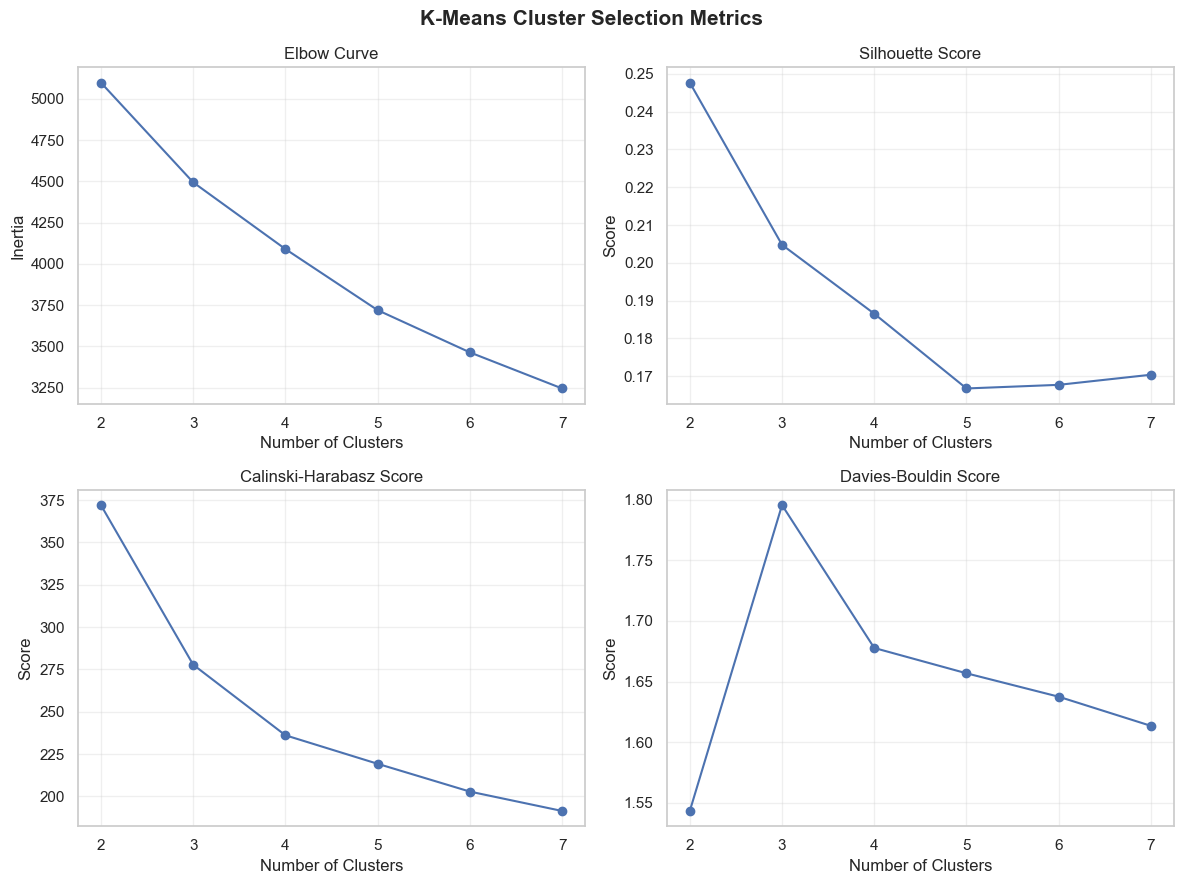

Cluster-selection figure saved to: ..\results\figures\vulnerability_clustering\kmeans_cluster_selection_metrics.png


In [9]:
# ==================================================
# Step 8: Visualize Cluster Selection Metrics
# ==================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

# Elbow curve
axes[0, 0].plot(
    cluster_selection_table["n_clusters"],
    cluster_selection_table["inertia"],
    marker="o"
)

axes[0, 0].set_title("Elbow Curve")
axes[0, 0].set_xlabel("Number of Clusters")
axes[0, 0].set_ylabel("Inertia")

# Silhouette score
axes[0, 1].plot(
    cluster_selection_table["n_clusters"],
    cluster_selection_table["silhouette_score"],
    marker="o"
)

axes[0, 1].set_title("Silhouette Score")
axes[0, 1].set_xlabel("Number of Clusters")
axes[0, 1].set_ylabel("Score")

# Calinski-Harabasz score
axes[1, 0].plot(
    cluster_selection_table["n_clusters"],
    cluster_selection_table["calinski_harabasz_score"],
    marker="o"
)

axes[1, 0].set_title("Calinski-Harabasz Score")
axes[1, 0].set_xlabel("Number of Clusters")
axes[1, 0].set_ylabel("Score")

# Davies-Bouldin score
axes[1, 1].plot(
    cluster_selection_table["n_clusters"],
    cluster_selection_table["davies_bouldin_score"],
    marker="o"
)

axes[1, 1].set_title("Davies-Bouldin Score")
axes[1, 1].set_xlabel("Number of Clusters")
axes[1, 1].set_ylabel("Score")

for axis in axes.flat:
    axis.set_xticks(
        cluster_selection_table["n_clusters"]
    )
    axis.grid(alpha=0.3)

plt.suptitle(
    "K-Means Cluster Selection Metrics",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

figure_path = (
    RESULTS_FIGURES
    / "kmeans_cluster_selection_metrics.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Cluster-selection figure saved to: {figure_path}")

## 9. Compare Candidate Cluster Profiles

Compare the 2-, 3-, and 4-cluster solutions using their cluster sizes and average standardized vulnerability profiles.

In [10]:
# ==================================================
# Step 9: Compare Candidate Cluster Profiles
# ==================================================

candidate_models = {}
candidate_labels = {}
candidate_profile_tables = {}
candidate_size_tables = {}

for k in [2, 3, 4]:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )
    
    labels = model.fit_predict(X_scaled)
    
    candidate_models[k] = model
    candidate_labels[k] = labels
    
    profile_data = scaled_clustering_data.copy()
    profile_data["cluster"] = labels
    
    cluster_profiles = (
        profile_data
        .groupby("cluster")[CLUSTERING_FEATURES]
        .mean()
        .round(3)
    )
    
    cluster_sizes = (
        pd.Series(labels, name="cluster")
        .value_counts()
        .sort_index()
        .rename("cluster_size")
        .to_frame()
    )
    
    cluster_sizes["cluster_share_pct"] = (
        cluster_sizes["cluster_size"]
        / len(labels)
        * 100
    ).round(2)
    
    candidate_profile_tables[k] = cluster_profiles
    candidate_size_tables[k] = cluster_sizes

for k in [2, 3, 4]:
    print(f"\n{k}-Cluster Solution")
    print("-" * 40)
    
    print("Cluster sizes")
    display(candidate_size_tables[k])
    
    print("Average standardized profiles")
    display(candidate_profile_tables[k])


2-Cluster Solution
----------------------------------------
Cluster sizes


,cluster_size,cluster_share_pct
cluster,,
0,570,57.0000
1,430,43.0000


Average standardized profiles


,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score
cluster,,,,,,,
0,0.5470,0.6210,0.2050,-0.4150,-0.3450,0.6040,0.2250
1,-0.7260,-0.8230,-0.2710,0.5500,0.4570,-0.8010,-0.2980



3-Cluster Solution
----------------------------------------
Cluster sizes


...

,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score
cluster,,,,,,,
0,-0.7540,-0.7740,-0.2350,0.7010,0.7090,-0.7940,-0.2540
1,-0.0640,0.0280,-0.2980,-0.6580,-1.1350,0.0620,-0.1940
2,0.8650,0.8160,0.4840,-0.2550,0.1030,0.8120,0.4240



4-Cluster Solution
----------------------------------------
Cluster sizes


,cluster_size,cluster_share_pct
cluster,,
0,171,17.1000
1,191,19.1000
2,284,28.4000
3,354,35.4000


Average standardized profiles


,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score
cluster,,,,,,,
0,-0.1780,-0.2300,-0.1550,-1.0610,-1.3830,-0.0480,-0.1190
1,1.0770,0.5250,1.2950,-0.5030,-0.1130,0.9060,0.2780
2,0.3410,0.8630,-0.4860,0.0950,0.0560,0.5250,0.2360
3,-0.7680,-0.8650,-0.2340,0.7080,0.6840,-0.8870,-0.2820


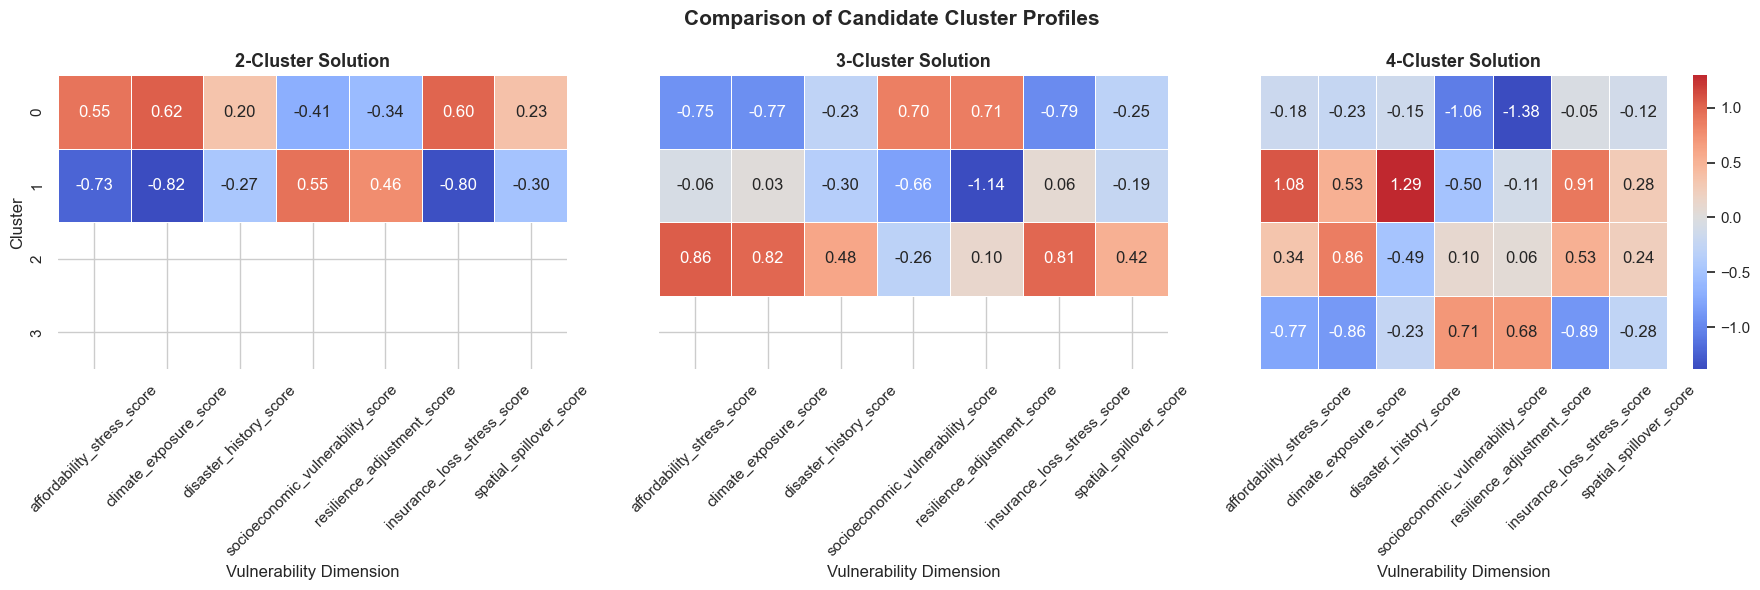

Candidate cluster profile figure saved to: ..\results\figures\vulnerability_clustering\candidate_cluster_profile_heatmaps.png


In [11]:
# ==================================================
# Step 10: Visualize Candidate Cluster Profiles
# ==================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    sharey=True
)

for axis, k in zip(axes, [2, 3, 4]):
    sns.heatmap(
        candidate_profile_tables[k],
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar=k == 4,
        ax=axis
    )
    
    axis.set_title(
        f"{k}-Cluster Solution",
        fontsize=13,
        fontweight="bold"
    )
    
    axis.set_xlabel("Vulnerability Dimension")
    axis.set_ylabel("Cluster" if k == 2 else "")
    axis.tick_params(axis="x", rotation=45)

plt.suptitle(
    "Comparison of Candidate Cluster Profiles",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

figure_path = (
    RESULTS_FIGURES
    / "candidate_cluster_profile_heatmaps.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Candidate cluster profile figure saved to: {figure_path}")

## 11. Select Final Number of Clusters

### Final Cluster-Count Selection

The internal validation metrics did not identify four clusters as the solution with the strongest geometric separation. The two-cluster solution produced the highest silhouette score of 0.2477, compared with 0.2048 for three clusters and 0.1865 for four clusters.

However, the purpose of the clustering analysis was not only to divide observations into broad lower-risk and higher-risk groups. That distinction was already available through the Low, Medium, and High vulnerability classes. The unsupervised analysis was intended to identify different combinations or pathways of vulnerability that could exist within similar overall vulnerability levels.

The two-cluster solution primarily produced a broad lower-stress versus higher-stress division. Although this solution achieved the strongest silhouette score, it combined substantively different forms of vulnerability into the same groups.

The three-cluster solution provided greater detail but still merged some important differences between:

- counties characterized by high underlying climate exposure;
- counties experiencing realized disaster and insurance-loss pressure;
- counties primarily affected by socioeconomic vulnerability and weaker resilience.

The four-cluster solution separated these dimensions into four interpretable profiles:

1. Lower-Stress Resilient Profile;
2. Disaster-Loss Growth Pressure;
3. High-Exposure Latent Risk;
4. Socioeconomic Resilience Stress.

The four-cluster solution was therefore retained because it provided the clearest balance between statistical quality, cluster size, substantive interpretation, and relevance to the research questions.

Solutions with five or more clusters produced lower silhouette scores, smaller groups, and more fragmented profiles without revealing sufficiently distinct additional vulnerability pathways.

K-Means was also the strongest of the tested four-cluster algorithms. It achieved a silhouette score of 0.1865, compared with 0.1468 for Agglomerative Clustering and 0.1172 for Gaussian Mixture Modelling. It also produced the strongest Calinski–Harabasz score and the lowest Davies–Bouldin score among the tested four-cluster methods.

The final solution was highly consistent across different K-Means random initializations, with Adjusted Rand Index values ranging from 0.9573 to 1.000. County-level bootstrap testing showed more moderate sample stability, with a mean out-of-bag ARI of 0.5251. This indicates that the four-profile structure is reproducible enough for exploratory interpretation, but the cluster boundaries are not rigid.

The four-cluster model is therefore interpreted as an exploratory vulnerability typology rather than proof that Florida counties form four perfectly separated natural groups. The profiles represent recurring combinations of climate exposure, disaster history, insurance losses, socioeconomic stress, resilience, affordability, and spatial pressure.

In [12]:
# ==================================================
# Step 11: Fit Final K-Means Model
# ==================================================

FINAL_N_CLUSTERS = 4

final_kmeans_model = KMeans(
    n_clusters=FINAL_N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=50
)

final_cluster_labels = final_kmeans_model.fit_predict(
    X_scaled
)

clustered_data = county_year_data.copy()
clustered_data["cluster_id"] = final_cluster_labels

final_cluster_sizes = (
    clustered_data["cluster_id"]
    .value_counts()
    .sort_index()
    .rename("cluster_size")
    .to_frame()
)

final_cluster_sizes["cluster_share_pct"] = (
    final_cluster_sizes["cluster_size"]
    / len(clustered_data)
    * 100
).round(2)

final_cluster_profiles = (
    scaled_clustering_data
    .assign(cluster_id=final_cluster_labels)
    .groupby("cluster_id")[CLUSTERING_FEATURES]
    .mean()
    .round(3)
)

print("Final K-Means model fitted successfully.")
print(f"Selected number of clusters: {FINAL_N_CLUSTERS}")
print(f"Total clustered observations: {len(clustered_data):,}")

print("\nFinal cluster sizes")
display(final_cluster_sizes)

print("Final standardized cluster profiles")
display(final_cluster_profiles)

Final K-Means model fitted successfully.
Selected number of clusters: 4
Total clustered observations: 1,000

Final cluster sizes


,cluster_size,cluster_share_pct
cluster_id,,
0,171,17.1000
1,191,19.1000
2,284,28.4000
3,354,35.4000


Final standardized cluster profiles


,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score
cluster_id,,,,,,,
0,-0.1780,-0.2300,-0.1550,-1.0610,-1.3830,-0.0480,-0.1190
1,1.0770,0.5250,1.2950,-0.5030,-0.1130,0.9060,0.2780
2,0.3410,0.8630,-0.4860,0.0950,0.0560,0.5250,0.2360
3,-0.7680,-0.8650,-0.2340,0.7080,0.6840,-0.8870,-0.2820


## 12. Compare Clustering Algorithms

Compare four-cluster solutions from K-Means, Gaussian Mixture Models, and Agglomerative Clustering.

In [13]:
# ==================================================
# Step 12: Compare Clustering Algorithms
# ==================================================

algorithm_comparison_results = []
algorithm_labels = {}

# ==================================================
# K-Means
# ==================================================

kmeans_labels = final_cluster_labels

algorithm_labels["K-Means"] = kmeans_labels

algorithm_comparison_results.append({
    "algorithm": "K-Means",
    "silhouette_score": silhouette_score(
        X_scaled,
        kmeans_labels
    ),
    "calinski_harabasz_score": calinski_harabasz_score(
        X_scaled,
        kmeans_labels
    ),
    "davies_bouldin_score": davies_bouldin_score(
        X_scaled,
        kmeans_labels
    ),
    "smallest_cluster_size": (
        pd.Series(kmeans_labels)
        .value_counts()
        .min()
    ),
    "largest_cluster_size": (
        pd.Series(kmeans_labels)
        .value_counts()
        .max()
    )
})

# ==================================================
# Gaussian Mixture Model
# ==================================================

gmm_model = GaussianMixture(
    n_components=FINAL_N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
    covariance_type="full"
)

gmm_labels = gmm_model.fit_predict(X_scaled)

algorithm_labels["Gaussian Mixture"] = gmm_labels

algorithm_comparison_results.append({
    "algorithm": "Gaussian Mixture",
    "silhouette_score": silhouette_score(
        X_scaled,
        gmm_labels
    ),
    "calinski_harabasz_score": calinski_harabasz_score(
        X_scaled,
        gmm_labels
    ),
    "davies_bouldin_score": davies_bouldin_score(
        X_scaled,
        gmm_labels
    ),
    "smallest_cluster_size": (
        pd.Series(gmm_labels)
        .value_counts()
        .min()
    ),
    "largest_cluster_size": (
        pd.Series(gmm_labels)
        .value_counts()
        .max()
    )
})

# ==================================================
# Agglomerative Clustering
# ==================================================

agglomerative_model = AgglomerativeClustering(
    n_clusters=FINAL_N_CLUSTERS,
    linkage="ward"
)

agglomerative_labels = agglomerative_model.fit_predict(
    X_scaled
)

algorithm_labels["Agglomerative"] = agglomerative_labels

algorithm_comparison_results.append({
    "algorithm": "Agglomerative",
    "silhouette_score": silhouette_score(
        X_scaled,
        agglomerative_labels
    ),
    "calinski_harabasz_score": calinski_harabasz_score(
        X_scaled,
        agglomerative_labels
    ),
    "davies_bouldin_score": davies_bouldin_score(
        X_scaled,
        agglomerative_labels
    ),
    "smallest_cluster_size": (
        pd.Series(agglomerative_labels)
        .value_counts()
        .min()
    ),
    "largest_cluster_size": (
        pd.Series(agglomerative_labels)
        .value_counts()
        .max()
    )
})

algorithm_comparison_table = pd.DataFrame(
    algorithm_comparison_results
)

print("Clustering algorithms compared successfully.")

display(
    algorithm_comparison_table.round(4)
)

Clustering algorithms compared successfully.


,algorithm,silhouette_score,calinski_harabasz_score,davies_bouldin_score,smallest_cluster_size,largest_cluster_size
0,K-Means,0.1865,236.1347,1.6777,171,354
1,Gaussian Mixture,0.1172,178.8036,2.1404,215,288
2,Agglomerative,0.1468,176.7855,2.0035,91,419


K-Means produced the strongest four-cluster solution, with the highest silhouette and Calinski–Harabasz scores and the lowest Davies–Bouldin score.

Gaussian Mixture Models produced more balanced cluster sizes but weaker separation, while Agglomerative Clustering created a comparatively small cluster and lower overall cluster quality.

K-Means was therefore retained as the final clustering method.

## 13. Check Cluster Stability

In [14]:
# ==================================================
# Step 13: Check Cluster Stability
# ==================================================

stability_results = []

test_seeds = [0, 1, 7, 21, 42, 99, 123]

for seed in test_seeds:
    stability_model = KMeans(
        n_clusters=FINAL_N_CLUSTERS,
        random_state=seed,
        n_init=50
    )
    
    stability_labels = stability_model.fit_predict(
        X_scaled
    )
    
    stability_results.append({
        "random_state": seed,
        "adjusted_rand_index": adjusted_rand_score(
            final_cluster_labels,
            stability_labels
        )
    })

cluster_stability_table = pd.DataFrame(
    stability_results
)

print("Cluster stability check completed.")

display(
    cluster_stability_table.round(4)
)

cluster_stability_table.to_csv(
    RESULTS_TABLES / "cluster_stability_results.csv",
    index=False
)

Cluster stability check completed.


,random_state,adjusted_rand_index
0,0,1.0000
1,1,1.0000
2,7,1.0000
3,21,0.9853
4,42,1.0000
5,99,0.9573
6,123,1.0000


## 14. Profile Final Clusters

Summarize the average vulnerability dimensions and housing-market conditions for each final cluster.

In [15]:
# ==================================================
# Step 14: Profile Final Clusters
# ==================================================

numeric_profiling_features = [
    feature for feature in available_profiling_features
    if feature != "vulnerability_class"
    and pd.api.types.is_numeric_dtype(clustered_data[feature])
]

cluster_profile_features = (
    CLUSTERING_FEATURES
    + numeric_profiling_features
)

final_cluster_profile_table = (
    clustered_data
    .groupby("cluster_id")[cluster_profile_features]
    .mean()
    .round(4)
)

final_cluster_profile_table.insert(
    0,
    "cluster_size",
    final_cluster_sizes["cluster_size"]
)

final_cluster_profile_table.insert(
    1,
    "cluster_share_pct",
    final_cluster_sizes["cluster_share_pct"]
)

print("Final cluster profiles created successfully.")

display(final_cluster_profile_table)

final_cluster_profile_table.to_csv(
    RESULTS_TABLES / "final_cluster_profiles.csv"
)

print(
    "Cluster profile table saved to: "
    f"{RESULTS_TABLES / 'final_cluster_profiles.csv'}"
)

Final cluster profiles created successfully.


,cluster_size,cluster_share_pct,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score,housing_pressure_score,annual_price_growth_pct,annual_price_volatility,avg_annual_housing_price,climate_housing_vulnerability_score
cluster_id,,,,,,,,,,,,,,
0,171,17.1000,0.4887,0.5624,0.2111,0.2824,0.3376,0.4269,0.4471,0.4381,4.2145,"5,142.7756","243,655.6336",0.3993
1,191,19.1000,0.5841,0.7583,0.5406,0.3535,0.6417,0.6524,0.5468,0.5368,8.9546,"9,132.9513","352,240.1625",0.5768
2,284,28.4000,0.5282,0.8463,0.1361,0.4296,0.6821,0.5623,0.5364,0.4639,7.0468,"5,951.1893","203,770.0468",0.5231
3,354,35.4000,0.4439,0.3975,0.1933,0.5077,0.8324,0.2287,0.4058,0.4225,5.1941,"3,378.7737","138,267.9764",0.4290


Cluster profile table saved to: ..\results\tables\vulnerability_clustering\final_cluster_profiles.csv


## 15. Name Final Clusters

Assign descriptive names to the four clusters based on their vulnerability and housing-market profiles.

In [16]:
# ==================================================
# Step 15: Name Final Clusters
# ==================================================

CLUSTER_NAMES = {
    0: "Lower-Stress Resilient Profile",
    1: "Disaster-Loss Growth Pressure",
    2: "High-Exposure Latent Risk",
    3: "Socioeconomic Resilience Stress"
}

clustered_data["cluster_name"] = (
    clustered_data["cluster_id"]
    .map(CLUSTER_NAMES)
)

cluster_name_table = (
    clustered_data[
        [
            "cluster_id",
            "cluster_name"
        ]
    ]
    .drop_duplicates()
    .sort_values("cluster_id")
    .merge(
        final_cluster_sizes.reset_index(),
        on="cluster_id",
        how="left"
    )
)

print("Descriptive cluster names assigned successfully.")

display(cluster_name_table)

cluster_name_table.to_csv(
    RESULTS_TABLES / "cluster_name_mapping.csv",
    index=False
)

print(
    "Cluster name mapping saved to: "
    f"{RESULTS_TABLES / 'cluster_name_mapping.csv'}"
)

Descriptive cluster names assigned successfully.


,cluster_id,cluster_name,cluster_size,cluster_share_pct
0,0,Lower-Stress Resilient Profile,171,17.1000
1,1,Disaster-Loss Growth Pressure,191,19.1000
2,2,High-Exposure Latent Risk,284,28.4000
3,3,Socioeconomic Resilience Stress,354,35.4000


Cluster name mapping saved to: ..\results\tables\vulnerability_clustering\cluster_name_mapping.csv


## 16. Visualize Final Cluster Profiles

Create a heatmap to compare the standardized vulnerability dimensions across the four named clusters.

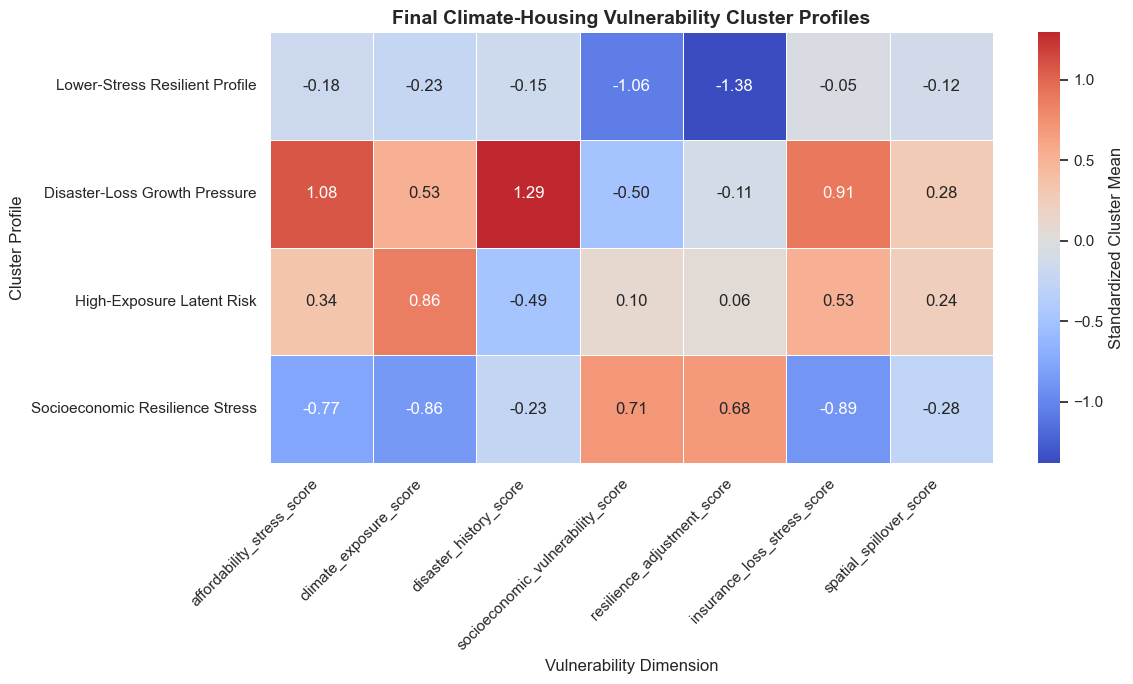

Final cluster profile heatmap saved to: ..\results\figures\vulnerability_clustering\final_cluster_profile_heatmap.png


In [17]:
# ==================================================
# Step 16: Visualize Final Cluster Profiles
# ==================================================

named_cluster_profiles = final_cluster_profiles.copy()

named_cluster_profiles.index = (
    named_cluster_profiles.index
    .map(CLUSTER_NAMES)
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    named_cluster_profiles,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={
        "label": "Standardized Cluster Mean"
    }
)

plt.title(
    "Final Climate-Housing Vulnerability Cluster Profiles",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Vulnerability Dimension")
plt.ylabel("Cluster Profile")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

figure_path = (
    RESULTS_FIGURES
    / "final_cluster_profile_heatmap.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Final cluster profile heatmap saved to: "
    f"{figure_path}"
)

## 17. Compare Housing-Market Conditions

Compare housing growth, housing pressure, price levels, and volatility across the four vulnerability profiles.

Housing-market conditions compared successfully.


,avg_annual_growth_pct,avg_housing_pressure_score,avg_annual_housing_price,avg_price_volatility_pct
cluster_name,,,,
Lower-Stress Resilient Profile,4.2145,0.4381,"243,655.6336",2.0920
Disaster-Loss Growth Pressure,8.9546,0.5368,"352,240.1625",2.5797
High-Exposure Latent Risk,7.0468,0.4639,"203,770.0468",2.8822
Socioeconomic Resilience Stress,5.1941,0.4225,"138,267.9764",2.3468


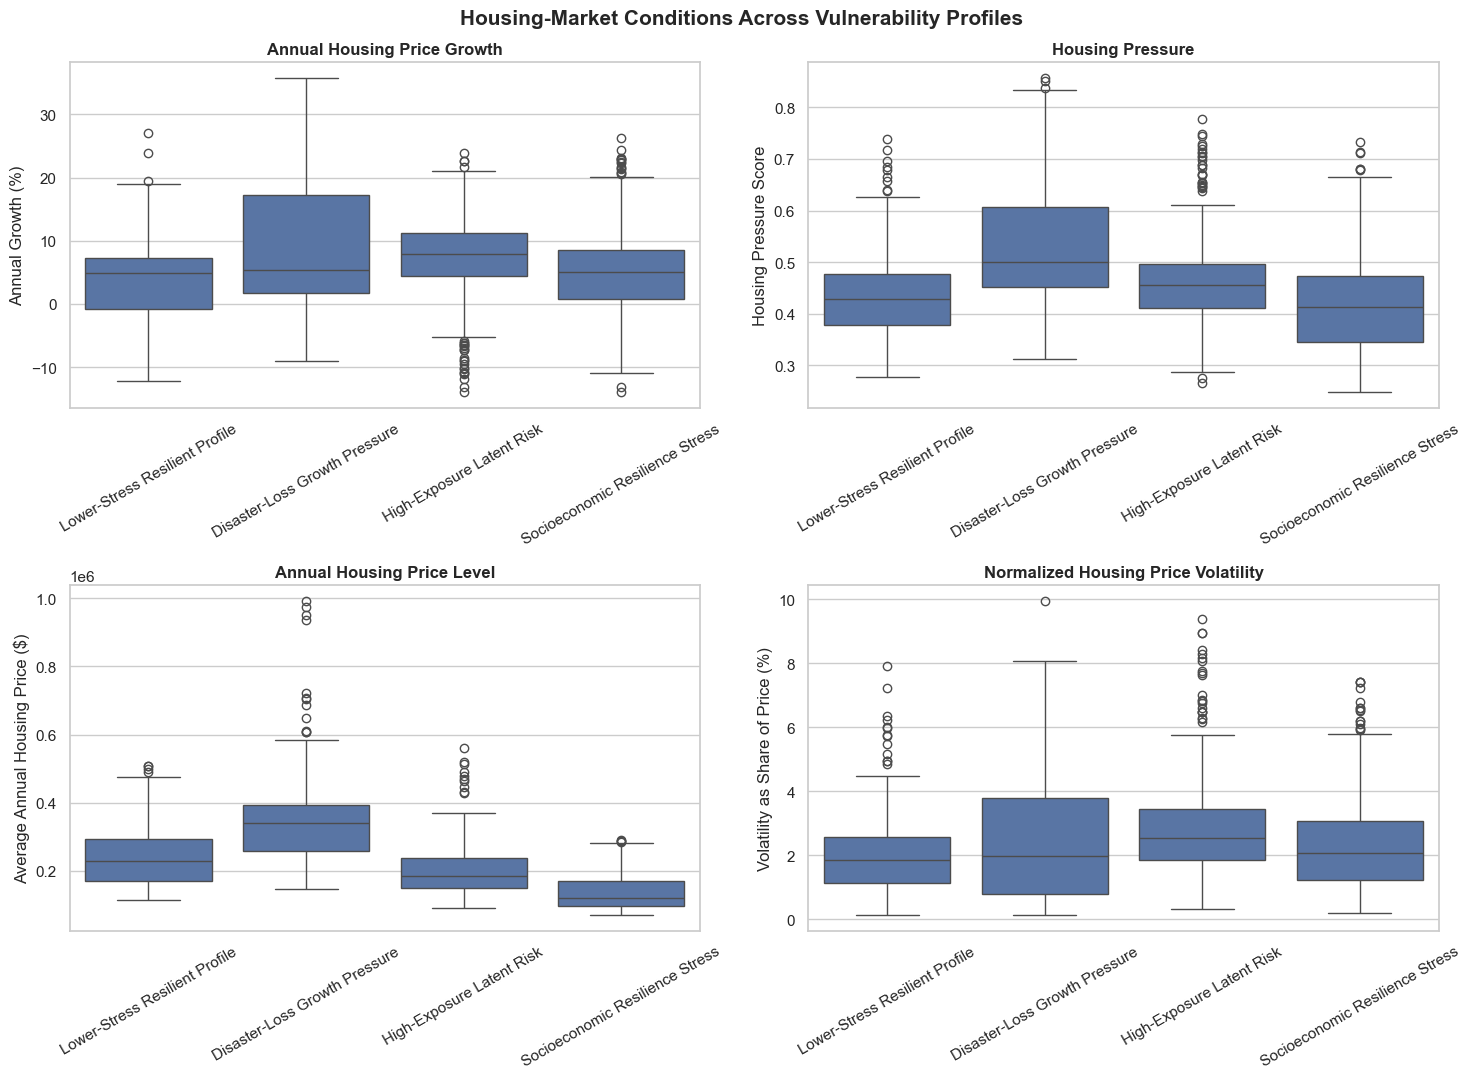

Housing-market comparison figure saved to: ..\results\figures\vulnerability_clustering\housing_market_conditions_by_cluster.png


In [18]:
# ==================================================
# Step 17: Compare Housing-Market Conditions
# ==================================================

clustered_data["annual_price_volatility_pct"] = (
    clustered_data["annual_price_volatility"]
    / clustered_data["avg_annual_housing_price"]
    * 100
)

housing_market_features = [
    "annual_price_growth_pct",
    "housing_pressure_score",
    "avg_annual_housing_price",
    "annual_price_volatility_pct"
]

housing_market_profile_table = (
    clustered_data
    .groupby("cluster_name")[housing_market_features]
    .mean()
    .reindex(CLUSTER_NAMES.values())
    .round(4)
)

housing_market_profile_table.columns = [
    "avg_annual_growth_pct",
    "avg_housing_pressure_score",
    "avg_annual_housing_price",
    "avg_price_volatility_pct"
]

print("Housing-market conditions compared successfully.")

display(housing_market_profile_table)

housing_market_profile_table.to_csv(
    RESULTS_TABLES / "cluster_housing_market_profiles.csv"
)

# ==================================================
# Housing-Market Comparison Figure
# ==================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11)
)

plot_settings = [
    (
        "annual_price_growth_pct",
        "Annual Housing Price Growth",
        "Annual Growth (%)"
    ),
    (
        "housing_pressure_score",
        "Housing Pressure",
        "Housing Pressure Score"
    ),
    (
        "avg_annual_housing_price",
        "Annual Housing Price Level",
        "Average Annual Housing Price ($)"
    ),
    (
        "annual_price_volatility_pct",
        "Normalized Housing Price Volatility",
        "Volatility as Share of Price (%)"
    )
]

cluster_order = list(CLUSTER_NAMES.values())

for axis, (feature, title, ylabel) in zip(
    axes.flat,
    plot_settings
):
    sns.boxplot(
        data=clustered_data,
        x="cluster_name",
        y=feature,
        order=cluster_order,
        ax=axis
    )

    axis.set_title(
        title,
        fontsize=12,
        fontweight="bold"
    )

    axis.set_xlabel("")
    axis.set_ylabel(ylabel)
    axis.tick_params(
        axis="x",
        rotation=30
    )

plt.suptitle(
    "Housing-Market Conditions Across Vulnerability Profiles",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

figure_path = (
    RESULTS_FIGURES
    / "housing_market_conditions_by_cluster.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Housing-market comparison figure saved to: "
    f"{figure_path}"
)

## 18. Compare Clusters with Vulnerability Classes

Examine how Low, Medium, and High vulnerability observations are distributed across the four cluster profiles.

Vulnerability-class composition calculated successfully.

Class counts by cluster


vulnerability_class,Low,Medium,High
cluster_name,,,
Lower-Stress Resilient Profile,118,49,4
Disaster-Loss Growth Pressure,1,46,144
High-Exposure Latent Risk,25,106,153
Socioeconomic Resilience Stress,190,132,32


Class percentages within each cluster


vulnerability_class,Low,Medium,High
cluster_name,,,
Lower-Stress Resilient Profile,69.0100,28.6500,2.3400
Disaster-Loss Growth Pressure,0.5200,24.0800,75.3900
High-Exposure Latent Risk,8.8000,37.3200,53.8700
Socioeconomic Resilience Stress,53.6700,37.2900,9.0400


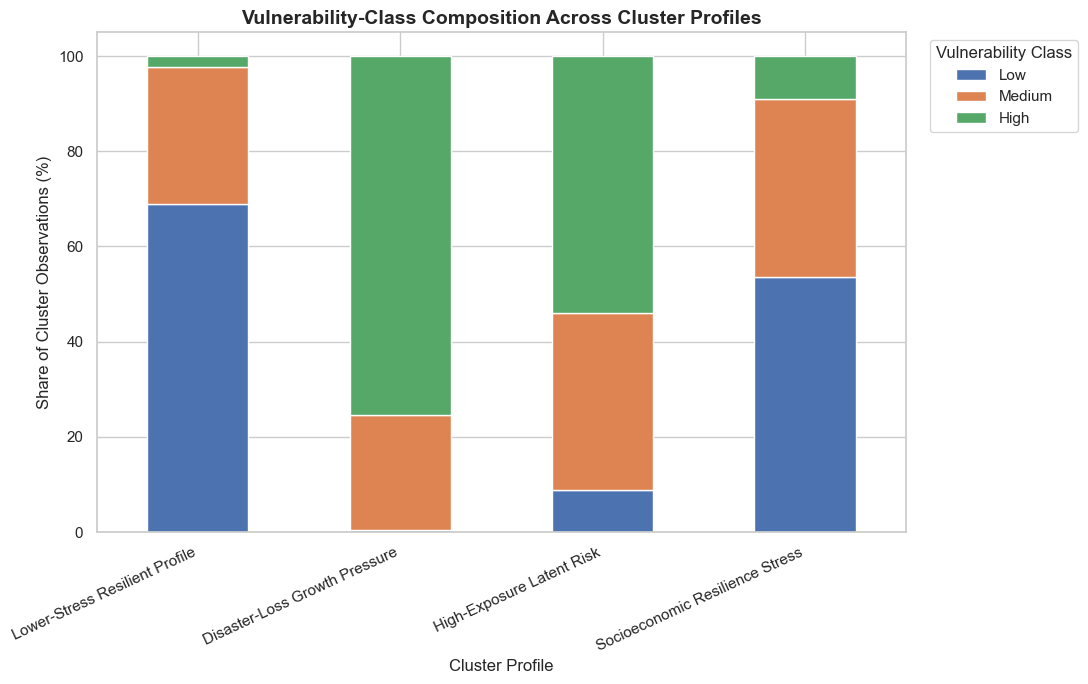

Vulnerability-class composition figure saved to: ..\results\figures\vulnerability_clustering\vulnerability_class_composition_by_cluster.png


In [19]:
# ==================================================
# Step 18: Compare Clusters with Vulnerability Classes
# ==================================================

vulnerability_class_order = [
    "Low",
    "Medium",
    "High"
]

cluster_order = list(CLUSTER_NAMES.values())

cluster_class_counts = pd.crosstab(
    clustered_data["cluster_name"],
    clustered_data["vulnerability_class"]
).reindex(
    index=cluster_order,
    columns=vulnerability_class_order,
    fill_value=0
)

cluster_class_percentages = (
    cluster_class_counts
    .div(cluster_class_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

print("Vulnerability-class composition calculated successfully.")

print("\nClass counts by cluster")
display(cluster_class_counts)

print("Class percentages within each cluster")
display(cluster_class_percentages)

cluster_class_counts.to_csv(
    RESULTS_TABLES / "cluster_vulnerability_class_counts.csv"
)

cluster_class_percentages.to_csv(
    RESULTS_TABLES / "cluster_vulnerability_class_percentages.csv"
)

# ==================================================
# Vulnerability-Class Composition Figure
# ==================================================

ax = cluster_class_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 7)
)

plt.title(
    "Vulnerability-Class Composition Across Cluster Profiles",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Cluster Profile")
plt.ylabel("Share of Cluster Observations (%)")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    title="Vulnerability Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

figure_path = (
    RESULTS_FIGURES
    / "vulnerability_class_composition_by_cluster.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Vulnerability-class composition figure saved to: "
    f"{figure_path}"
)

## 18.1. Check Temporal Prevalence and Year Dependence

Examine how the four vulnerability profiles are distributed across the 2011–2025 study period.

This check is important because some clustering dimensions, particularly disaster history and insurance-loss stress, include cumulative or recent-history information that may change systematically over time. If certain clusters appear almost exclusively in earlier or later years, the clustering may partly reflect temporal change rather than only differences between county vulnerability structures.

Annual cluster counts, annual percentage shares, five-year period comparisons, and Cramér’s V are used to assess the strength of the relationship between year and cluster membership.

Temporal cluster-prevalence analysis completed.
Study period: 2011–2025

Annual cluster counts


cluster_name,Lower-Stress Resilient Profile,Disaster-Loss Growth Pressure,High-Exposure Latent Risk,Socioeconomic Resilience Stress
Year,,,,
2011,13,0,20,33
2012,13,0,23,30
2013,9,0,28,29
2014,10,0,28,28
2015,11,0,29,26
2016,11,1,32,23
2017,11,19,14,23
2018,12,5,28,22
2019,15,8,21,23


Annual cluster percentage shares


cluster_name,Lower-Stress Resilient Profile,Disaster-Loss Growth Pressure,High-Exposure Latent Risk,Socioeconomic Resilience Stress
Year,,,,
2011,19.7000,0.0000,30.3000,50.0000
2012,19.7000,0.0000,34.8500,45.4500
2013,13.6400,0.0000,42.4200,43.9400
2014,15.1500,0.0000,42.4200,42.4200
2015,16.6700,0.0000,43.9400,39.3900
2016,16.4200,1.4900,47.7600,34.3300
2017,16.4200,28.3600,20.9000,34.3300
2018,17.9100,7.4600,41.7900,32.8400
2019,22.3900,11.9400,31.3400,34.3300


Cluster counts by five-year period


...

Year distribution within each cluster


,observation_count,unique_counties,minimum_year,median_year,mean_year,maximum_year
cluster_name,,,,,,
Lower-Stress Resilient Profile,171,21,2011,"2,018.0000","2,018.0200",2025
Disaster-Loss Growth Pressure,191,55,2016,"2,022.0000","2,021.9700",2025
High-Exposure Latent Risk,284,38,2011,"2,016.0000","2,016.3500",2025
Socioeconomic Resilience Stress,354,34,2011,"2,017.0000","2,017.2400",2025


Association between year and cluster membership


,metric,value
0,Chi-square statistic,428.6754
1,Degrees of freedom,42.0000
2,P-value,0.0000
3,Bias-corrected Cramér's V,0.3595


Bias-corrected Cramér's V: 0.3595


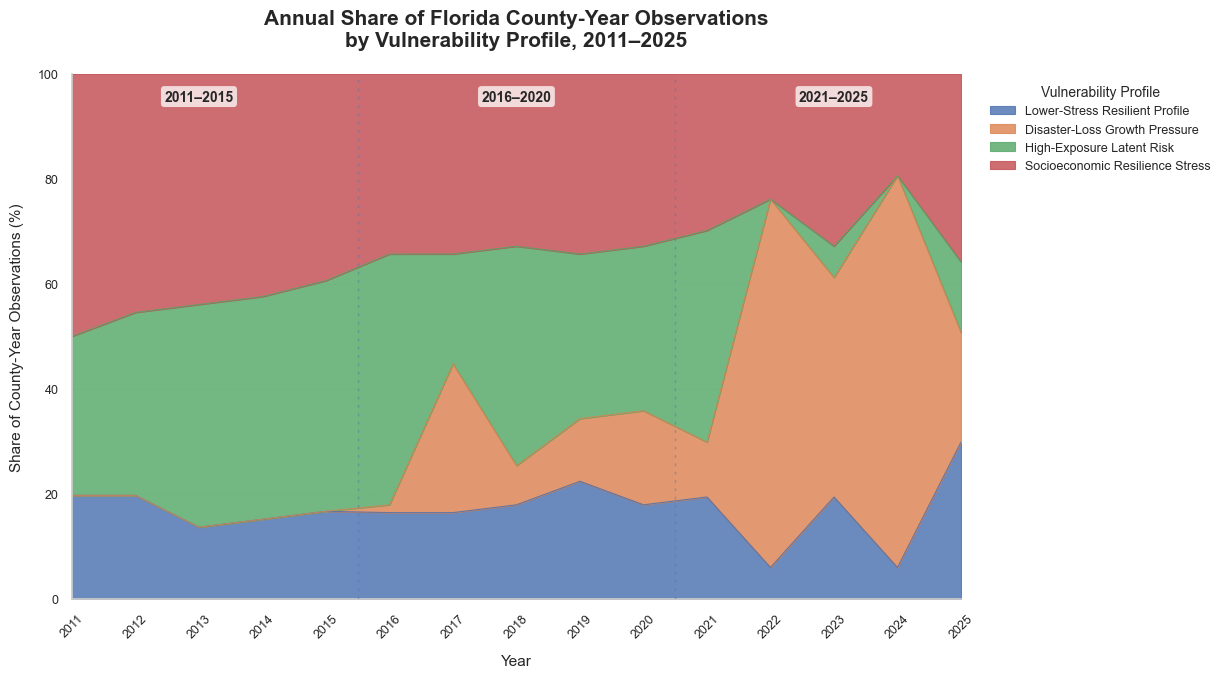

Temporal cluster tables and figure saved successfully.
Figure saved to: ..\results\figures\vulnerability_clustering\annual_cluster_prevalence_2011_2025.png


In [20]:
# ==================================================
# Step 18.1: Check Temporal Cluster Prevalence
# ==================================================

from scipy.stats import chi2_contingency

cluster_order = [
    CLUSTER_NAMES[cluster_id]
    for cluster_id in sorted(CLUSTER_NAMES)
]

year_order = list(
    range(
        int(clustered_data["Year"].min()),
        int(clustered_data["Year"].max()) + 1
    )
)

# ==================================================
# Annual Cluster Counts
# ==================================================

annual_cluster_counts = (
    pd.crosstab(
        clustered_data["Year"],
        clustered_data["cluster_name"]
    )
    .reindex(
        index=year_order,
        columns=cluster_order,
        fill_value=0
    )
)

annual_cluster_counts.index.name = "Year"

# ==================================================
# Annual Cluster Percentage Shares
# ==================================================

annual_cluster_shares = (
    annual_cluster_counts
    .div(
        annual_cluster_counts.sum(axis=1),
        axis=0
    )
    .mul(100)
    .round(2)
)

# ==================================================
# Define Five-Year Study Periods
# ==================================================

temporal_cluster_data = clustered_data[
    [
        "STCOFIPS",
        "RegionName",
        "Year",
        "cluster_id",
        "cluster_name"
    ]
].copy()

temporal_cluster_data["study_period"] = np.select(
    [
        temporal_cluster_data["Year"].between(2011, 2015),
        temporal_cluster_data["Year"].between(2016, 2020),
        temporal_cluster_data["Year"].between(2021, 2025)
    ],
    [
        "2011–2015",
        "2016–2020",
        "2021–2025"
    ],
    default="Other"
)

period_order = [
    "2011–2015",
    "2016–2020",
    "2021–2025"
]

# ==================================================
# Cluster Counts and Shares by Study Period
# ==================================================

period_cluster_counts = (
    pd.crosstab(
        temporal_cluster_data["study_period"],
        temporal_cluster_data["cluster_name"]
    )
    .reindex(
        index=period_order,
        columns=cluster_order,
        fill_value=0
    )
)

period_cluster_shares = (
    period_cluster_counts
    .div(
        period_cluster_counts.sum(axis=1),
        axis=0
    )
    .mul(100)
    .round(2)
)

# ==================================================
# Year Distribution Within Each Cluster
# ==================================================

cluster_year_summary = (
    temporal_cluster_data
    .groupby("cluster_name")
    .agg(
        observation_count=("Year", "size"),
        unique_counties=("STCOFIPS", "nunique"),
        minimum_year=("Year", "min"),
        median_year=("Year", "median"),
        mean_year=("Year", "mean"),
        maximum_year=("Year", "max")
    )
    .reindex(cluster_order)
    .round(2)
)

# ==================================================
# Test Relationship Between Year and Cluster
# ==================================================

year_cluster_contingency = pd.crosstab(
    temporal_cluster_data["Year"],
    temporal_cluster_data["cluster_name"]
)

chi_square_statistic, chi_square_p_value, degrees_freedom, expected = (
    chi2_contingency(year_cluster_contingency)
)

sample_size = year_cluster_contingency.to_numpy().sum()
rows, columns = year_cluster_contingency.shape

# Bias-corrected Cramér's V
phi_squared = chi_square_statistic / sample_size

phi_squared_corrected = max(
    0,
    phi_squared
    - ((columns - 1) * (rows - 1))
    / (sample_size - 1)
)

rows_corrected = (
    rows
    - ((rows - 1) ** 2)
    / (sample_size - 1)
)

columns_corrected = (
    columns
    - ((columns - 1) ** 2)
    / (sample_size - 1)
)

cramers_v = np.sqrt(
    phi_squared_corrected
    / min(
        columns_corrected - 1,
        rows_corrected - 1
    )
)

temporal_association_table = pd.DataFrame({
    "metric": [
        "Chi-square statistic",
        "Degrees of freedom",
        "P-value",
        "Bias-corrected Cramér's V"
    ],
    "value": [
        chi_square_statistic,
        degrees_freedom,
        chi_square_p_value,
        cramers_v
    ]
})

# ==================================================
# Display Temporal Results
# ==================================================

print("Temporal cluster-prevalence analysis completed.")
print(
    f"Study period: "
    f"{temporal_cluster_data['Year'].min()}–"
    f"{temporal_cluster_data['Year'].max()}"
)

print("\nAnnual cluster counts")
display(annual_cluster_counts)

print("Annual cluster percentage shares")
display(annual_cluster_shares)

print("Cluster counts by five-year period")
display(period_cluster_counts)

print("Cluster percentage shares by five-year period")
display(period_cluster_shares)

print("Year distribution within each cluster")
display(cluster_year_summary)

print("Association between year and cluster membership")
display(temporal_association_table.round(4))

print(
    f"Bias-corrected Cramér's V: "
    f"{cramers_v:.4f}"
)

# ==================================================
# Visualize Annual Cluster Shares
# ==================================================

fig, ax = plt.subplots(
    figsize=(14, 7.5)
)

annual_cluster_shares.plot.area(
    stacked=True,
    alpha=0.82,
    linewidth=0.8,
    ax=ax
)

# ==================================================
# Add Subtle Study-Period Background Shading
# ==================================================

# First period: 2011–2015
ax.axvspan(
    2010.5,
    2015.5,
    alpha=0.025,
    zorder=0
)

# Second period: 2016–2020
ax.axvspan(
    2015.5,
    2020.5,
    alpha=0.06,
    zorder=0
)

# Third period: 2021–2025
ax.axvspan(
    2020.5,
    2025.5,
    alpha=0.025,
    zorder=0
)

# ==================================================
# Add Subtle Period Separators
# ==================================================

for boundary_year in [2015.5, 2020.5]:
    ax.axvline(
        x=boundary_year,
        linestyle=(0, (2, 4)),
        linewidth=1.0,
        alpha=0.45,
        zorder=4
    )

# ==================================================
# Add Study-Period Labels Inside Plot
# ==================================================

period_labels = [
    (2013, "2011–2015"),
    (2018, "2016–2020"),
    (2023, "2021–2025")
]

for x_position, label in period_labels:
    ax.text(
        x_position,
        97,
        label,
        ha="center",
        va="top",
        fontsize=10,
        fontweight="semibold",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.75
        },
        zorder=6
    )

# ==================================================
# Titles and Axis Formatting
# ==================================================

ax.set_title(
    "Annual Share of Florida County-Year Observations\n"
    "by Vulnerability Profile, 2011–2025",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Year",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "Share of County-Year Observations (%)",
    fontsize=11,
    labelpad=10
)

ax.set_ylim(0, 100)

ax.set_xlim(
    annual_cluster_shares.index.min(),
    annual_cluster_shares.index.max()
)

ax.set_xticks(year_order)

ax.tick_params(
    axis="x",
    rotation=45,
    labelsize=9
)

ax.tick_params(
    axis="y",
    labelsize=9
)

# Use only light horizontal gridlines
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.3
)

ax.grid(
    axis="x",
    visible=False
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ==================================================
# Legend
# ==================================================

ax.legend(
    title="Vulnerability Profile",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

# Reserve space for the external legend and title
fig.subplots_adjust(
    top=0.86,
    right=0.76,
    bottom=0.16
)

# ==================================================
# Save Figure
# ==================================================

temporal_figure_path = (
    RESULTS_FIGURES
    / "annual_cluster_prevalence_2011_2025.png"
)

plt.savefig(
    temporal_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# ==================================================
# Save Temporal Analysis Outputs
# ==================================================

annual_cluster_counts.to_csv(
    RESULTS_TABLES / "annual_cluster_counts.csv"
)

annual_cluster_shares.to_csv(
    RESULTS_TABLES / "annual_cluster_shares_pct.csv"
)

period_cluster_counts.to_csv(
    RESULTS_TABLES / "cluster_counts_by_study_period.csv"
)

period_cluster_shares.to_csv(
    RESULTS_TABLES / "cluster_shares_by_study_period_pct.csv"
)

cluster_year_summary.to_csv(
    RESULTS_TABLES / "cluster_year_distribution_summary.csv"
)

temporal_association_table.to_csv(
    RESULTS_TABLES / "year_cluster_association_results.csv",
    index=False
)

print(
    "Temporal cluster tables and figure saved successfully."
)

print(
    f"Figure saved to: {temporal_figure_path}"
)

### Interpretation

The temporal analysis shows that vulnerability-profile membership changed meaningfully across the 2011–2025 study period. The association between year and cluster membership was statistically significant, with a bias-corrected Cramér’s V of 0.3595, indicating a moderate relationship.

The Disaster-Loss Growth Pressure profile was strongly concentrated in recent years. It represented none of the observations during 2011–2015, 13.43% during 2016–2020, and 43.58% during 2021–2025. Its concentration was particularly high in 2022 and 2024, when it accounted for 70.15% and 74.63% of county-year observations, respectively. This suggests that the profile partly represents a recent vulnerability regime characterized by accumulated disaster experience, insurance-loss stress and housing-market pressure.

In contrast, the High-Exposure Latent Risk profile declined from 38.79% of observations during 2011–2015 to 11.94% during 2021–2025. This pattern suggests that some counties previously characterized mainly by underlying physical exposure may have shifted toward a realized disaster-loss profile as losses and related pressures accumulated.

The Lower-Stress Resilient Profile remained relatively stable across the three five-year periods, while Socioeconomic Resilience Stress appeared throughout the full study period. These patterns show that the clustering is not determined by year alone. Multiple profiles occur within the same year, including all four profiles in 2025.

The clusters should therefore be interpreted as recurring county-year vulnerability states rather than fixed and permanent county categories. Their changing annual prevalence provides evidence that county vulnerability can evolve as disaster history, insurance losses, affordability and resilience conditions change.

## 18.2. Recent County-Level Robustness Check

The main clustering analysis uses county-year observations, meaning that the same county may appear up to 15 times across the study period. Because observations from the same county are related, a supplementary county-level robustness analysis is conducted.

For each Florida county, the seven clustering dimensions are averaged across 2021–2025. This produces one recent-period vulnerability profile per county. K-Means is then applied to these county-level profiles, and the resulting clusters are compared with the four profiles identified in the full county-year analysis.

The purpose is not to reproduce every county-year assignment exactly. Instead, the analysis examines whether broadly similar vulnerability profiles remain visible after repeated yearly observations are removed.

Recent county-level profiles created successfully.
Recent period: 2021–2025
County profiles created: 67
Counties with all five recent years: 67

Recent county-level cluster-selection results


,n_clusters,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,smallest_cluster_size,largest_cluster_size
0,2,181.7857,0.3508,42.2536,1.1261,28,39
1,3,141.6077,0.3046,35.7831,1.2101,18,25
2,4,118.5662,0.3077,32.1271,1.2006,6,25
3,5,105.0986,0.2502,28.7377,1.2996,6,19
4,6,94.8205,0.2390,26.3936,1.2502,3,18



Recent-to-original cluster alignment


,recent_raw_cluster,matched_original_cluster,matched_profile
2,2,0,Lower-Stress Resilient Profile
0,0,1,Disaster-Loss Growth Pressure
3,3,2,High-Exposure Latent Risk
1,1,3,Socioeconomic Resilience Stress



Original versus recent centroid similarity


,cluster_id,cluster_name,matched_recent_raw_cluster,euclidean_centroid_distance,profile_correlation,cosine_similarity
0,0,Lower-Stress Resilient Profile,2,1.7209,0.8444,0.8414
1,1,Disaster-Loss Growth Pressure,0,0.9072,0.8826,0.9261
2,2,High-Exposure Latent Risk,3,2.0704,-0.0110,0.0942
3,3,Socioeconomic Resilience Stress,1,1.5591,0.6785,0.5931



County-level robustness summary


,metric,value
0,Recent county profiles,67.0000
1,Exact profile agreement (%),64.1791
2,Adjusted Rand Index,0.4440


Assignment comparison matrix


robustness_cluster_name,Lower-Stress Resilient Profile,Disaster-Loss Growth Pressure,High-Exposure Latent Risk,Socioeconomic Resilience Stress
dominant_main_cluster_name,,,,
Lower-Stress Resilient Profile,6,0,6,0
Disaster-Loss Growth Pressure,0,15,11,4
High-Exposure Latent Risk,0,3,1,0
Socioeconomic Resilience Stress,0,0,0,21


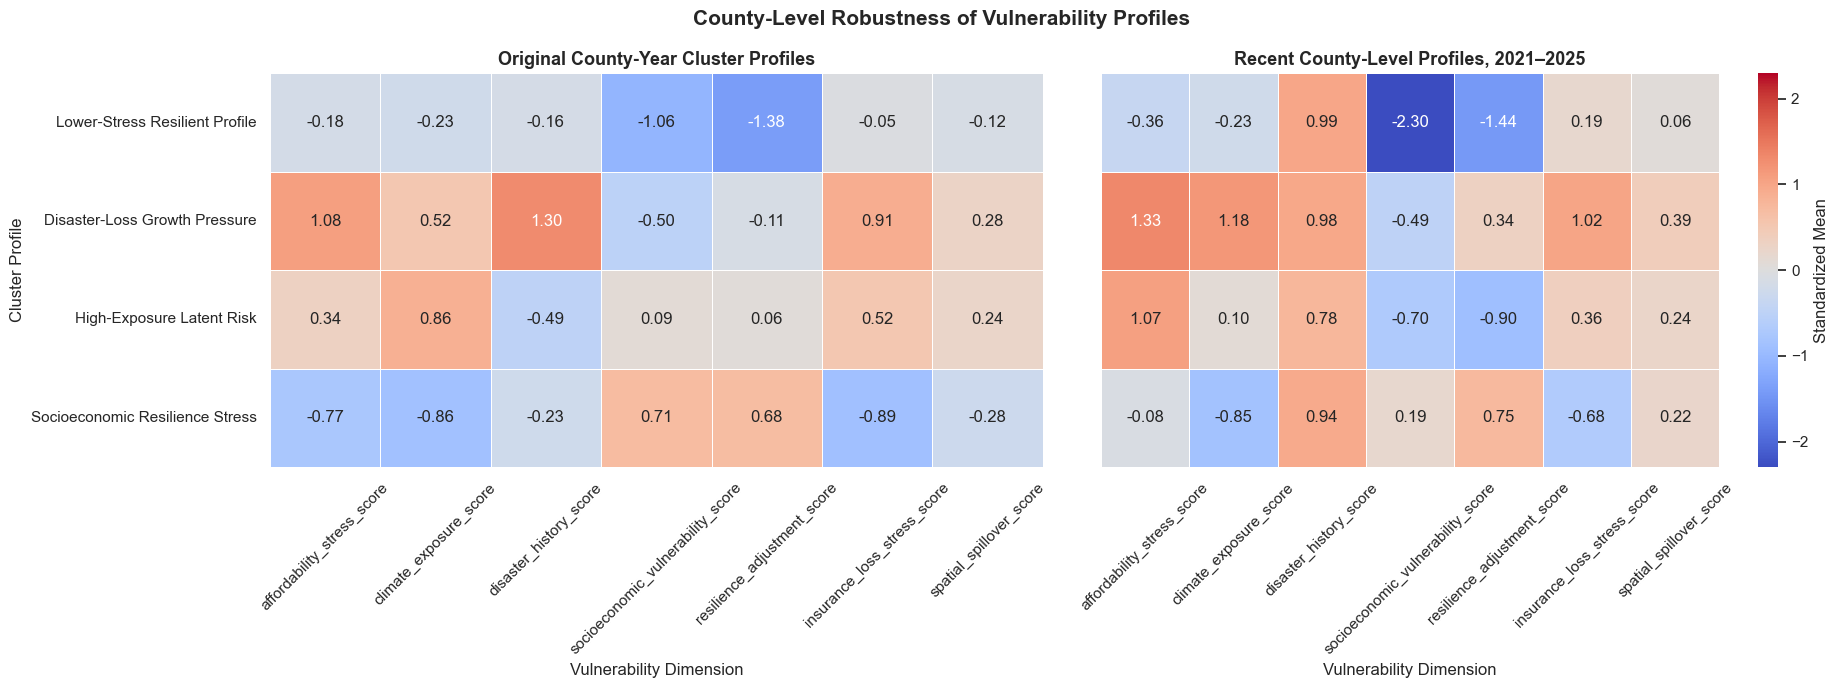

Recent county-level robustness outputs saved successfully.
Figure saved to: ..\results\figures\vulnerability_clustering\recent_county_level_cluster_robustness.png


In [21]:
# ==================================================
# Step 18.2: Recent County-Level Robustness Check
# ==================================================

from scipy.optimize import linear_sum_assignment

RECENT_ROBUSTNESS_START_YEAR = 2021
RECENT_ROBUSTNESS_END_YEAR = 2025

# ==================================================
# Create One Recent Profile Per County
# ==================================================

recent_period_data = clustered_data[
    clustered_data["Year"].between(
        RECENT_ROBUSTNESS_START_YEAR,
        RECENT_ROBUSTNESS_END_YEAR
    )
].copy()

recent_county_profiles = (
    recent_period_data
    .groupby(
        [
            "STCOFIPS",
            "RegionName"
        ],
        as_index=False
    )
    .agg(
        {
            **{
                feature: "mean"
                for feature in CLUSTERING_FEATURES
            },
            "Year": "nunique"
        }
    )
    .rename(
        columns={
            "Year": "recent_years_observed"
        }
    )
)

print("Recent county-level profiles created successfully.")
print(
    f"Recent period: "
    f"{RECENT_ROBUSTNESS_START_YEAR}–"
    f"{RECENT_ROBUSTNESS_END_YEAR}"
)
print(
    f"County profiles created: "
    f"{len(recent_county_profiles)}"
)
print(
    f"Counties with all five recent years: "
    f"{(
        recent_county_profiles['recent_years_observed'] == 5
    ).sum()}"
)

# ==================================================
# Transform Using the Original County-Year Scaler
# ==================================================
#
# Using the original scaler keeps the recent county
# centroids in the same standardized feature space as
# the main county-year model.
# ==================================================

X_recent_county_scaled = scaler.transform(
    recent_county_profiles[CLUSTERING_FEATURES]
)

# ==================================================
# Evaluate Candidate Cluster Counts
# ==================================================

recent_county_selection_results = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )

    labels = model.fit_predict(
        X_recent_county_scaled
    )

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
    )

    recent_county_selection_results.append({
        "n_clusters": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(
            X_recent_county_scaled,
            labels
        ),
        "calinski_harabasz_score":
            calinski_harabasz_score(
                X_recent_county_scaled,
                labels
            ),
        "davies_bouldin_score":
            davies_bouldin_score(
                X_recent_county_scaled,
                labels
            ),
        "smallest_cluster_size":
            cluster_sizes.min(),
        "largest_cluster_size":
            cluster_sizes.max()
    })

recent_county_selection_table = pd.DataFrame(
    recent_county_selection_results
)

print("\nRecent county-level cluster-selection results")
display(
    recent_county_selection_table.round(4)
)

# ==================================================
# Fit Four-Cluster County-Level Robustness Model
# ==================================================

recent_county_kmeans_model = KMeans(
    n_clusters=FINAL_N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=50
)

recent_county_raw_labels = (
    recent_county_kmeans_model.fit_predict(
        X_recent_county_scaled
    )
)

recent_county_profiles[
    "robustness_cluster_raw"
] = recent_county_raw_labels

# ==================================================
# Align New Cluster IDs with Original Cluster IDs
# ==================================================
#
# K-Means cluster numbers are arbitrary. The Hungarian
# algorithm finds the one-to-one matching that minimizes
# distance between recent county-level centroids and the
# original county-year centroids.
# ==================================================

centroid_distance_matrix = np.linalg.norm(
    recent_county_kmeans_model.cluster_centers_[:, None, :]
    - final_kmeans_model.cluster_centers_[None, :, :],
    axis=2
)

recent_rows, original_columns = (
    linear_sum_assignment(
        centroid_distance_matrix
    )
)

recent_to_original_mapping = {
    int(recent_cluster_id):
        int(original_cluster_id)
    for recent_cluster_id, original_cluster_id
    in zip(
        recent_rows,
        original_columns
    )
}

recent_county_profiles[
    "robustness_cluster_id"
] = (
    recent_county_profiles[
        "robustness_cluster_raw"
    ]
    .map(recent_to_original_mapping)
)

recent_county_profiles[
    "robustness_cluster_name"
] = (
    recent_county_profiles[
        "robustness_cluster_id"
    ]
    .map(CLUSTER_NAMES)
)

print("\nRecent-to-original cluster alignment")
display(
    pd.DataFrame({
        "recent_raw_cluster":
            list(recent_to_original_mapping.keys()),
        "matched_original_cluster":
            list(recent_to_original_mapping.values())
    })
    .assign(
        matched_profile=lambda data:
            data["matched_original_cluster"]
            .map(CLUSTER_NAMES)
    )
    .sort_values("matched_original_cluster")
)

# ==================================================
# Create Aligned Recent Cluster Profile Table
# ==================================================

recent_centers_aligned = pd.DataFrame(
    index=range(FINAL_N_CLUSTERS),
    columns=CLUSTERING_FEATURES,
    dtype=float
)

for (
    recent_cluster_id,
    original_cluster_id
) in recent_to_original_mapping.items():

    recent_centers_aligned.loc[
        original_cluster_id
    ] = (
        recent_county_kmeans_model
        .cluster_centers_[
            recent_cluster_id
        ]
    )

recent_centers_aligned.index.name = "cluster_id"

recent_centers_aligned_named = (
    recent_centers_aligned.copy()
)

recent_centers_aligned_named.index = (
    recent_centers_aligned_named.index
    .map(CLUSTER_NAMES)
)

# Exact original centroids
original_centers_table = pd.DataFrame(
    final_kmeans_model.cluster_centers_,
    columns=CLUSTERING_FEATURES,
    index=range(FINAL_N_CLUSTERS)
)

original_centers_table.index.name = "cluster_id"

original_centers_named = (
    original_centers_table.copy()
)

original_centers_named.index = (
    original_centers_named.index
    .map(CLUSTER_NAMES)
)

# ==================================================
# Compare Original and Recent Profile Shapes
# ==================================================

centroid_similarity_results = []

for original_cluster_id in range(
    FINAL_N_CLUSTERS
):

    recent_cluster_id = next(
        recent_id
        for recent_id, matched_original_id
        in recent_to_original_mapping.items()
        if matched_original_id
        == original_cluster_id
    )

    original_centroid = (
        final_kmeans_model.cluster_centers_[
            original_cluster_id
        ]
    )

    recent_centroid = (
        recent_county_kmeans_model
        .cluster_centers_[
            recent_cluster_id
        ]
    )

    euclidean_distance = np.linalg.norm(
        original_centroid
        - recent_centroid
    )

    profile_correlation = np.corrcoef(
        original_centroid,
        recent_centroid
    )[0, 1]

    cosine_denominator = (
        np.linalg.norm(original_centroid)
        * np.linalg.norm(recent_centroid)
    )

    cosine_similarity = (
        np.dot(
            original_centroid,
            recent_centroid
        )
        / cosine_denominator
        if cosine_denominator != 0
        else np.nan
    )

    centroid_similarity_results.append({
        "cluster_id":
            original_cluster_id,
        "cluster_name":
            CLUSTER_NAMES[
                original_cluster_id
            ],
        "matched_recent_raw_cluster":
            recent_cluster_id,
        "euclidean_centroid_distance":
            euclidean_distance,
        "profile_correlation":
            profile_correlation,
        "cosine_similarity":
            cosine_similarity
    })

centroid_similarity_table = pd.DataFrame(
    centroid_similarity_results
)

print("\nOriginal versus recent centroid similarity")
display(
    centroid_similarity_table.round(4)
)

# ==================================================
# Calculate Dominant 2021–2025 Main-Model Profile
# ==================================================

dominant_recent_counts = (
    recent_period_data
    .groupby(
        [
            "STCOFIPS",
            "RegionName",
            "cluster_id",
            "cluster_name"
        ]
    )
    .size()
    .reset_index(
        name="years_in_main_profile"
    )
)

dominant_recent_counts = (
    dominant_recent_counts
    .sort_values(
        [
            "STCOFIPS",
            "years_in_main_profile",
            "cluster_id"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
    .drop_duplicates(
        subset="STCOFIPS"
    )
    .rename(
        columns={
            "cluster_id":
                "dominant_main_cluster_id",
            "cluster_name":
                "dominant_main_cluster_name"
        }
    )
)

# ==================================================
# Compare County Assignments
# ==================================================

county_robustness_comparison = (
    recent_county_profiles
    .merge(
        dominant_recent_counts[
            [
                "STCOFIPS",
                "dominant_main_cluster_id",
                "dominant_main_cluster_name",
                "years_in_main_profile"
            ]
        ],
        on="STCOFIPS",
        how="left"
    )
)

county_robustness_comparison[
    "profile_assignment_agreement"
] = (
    county_robustness_comparison[
        "robustness_cluster_id"
    ]
    == county_robustness_comparison[
        "dominant_main_cluster_id"
    ]
)

assignment_agreement_pct = (
    county_robustness_comparison[
        "profile_assignment_agreement"
    ]
    .mean()
    * 100
)

county_level_ari = adjusted_rand_score(
    county_robustness_comparison[
        "dominant_main_cluster_id"
    ],
    county_robustness_comparison[
        "robustness_cluster_id"
    ]
)

assignment_comparison_matrix = pd.crosstab(
    county_robustness_comparison[
        "dominant_main_cluster_name"
    ],
    county_robustness_comparison[
        "robustness_cluster_name"
    ]
).reindex(
    index=list(CLUSTER_NAMES.values()),
    columns=list(CLUSTER_NAMES.values()),
    fill_value=0
)

robustness_summary_table = pd.DataFrame({
    "metric": [
        "Recent county profiles",
        "Exact profile agreement (%)",
        "Adjusted Rand Index"
    ],
    "value": [
        len(county_robustness_comparison),
        assignment_agreement_pct,
        county_level_ari
    ]
})

print("\nCounty-level robustness summary")
display(
    robustness_summary_table.round(4)
)

print("Assignment comparison matrix")
display(
    assignment_comparison_matrix
)

# ==================================================
# Compare Original and Recent Profiles Visually
# ==================================================

combined_centers = pd.concat(
    [
        original_centers_named,
        recent_centers_aligned_named
    ]
)

maximum_absolute_value = (
    combined_centers
    .abs()
    .to_numpy()
    .max()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(19, 7),
    sharey=True
)

sns.heatmap(
    original_centers_named,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-maximum_absolute_value,
    vmax=maximum_absolute_value,
    linewidths=0.5,
    cbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "Original County-Year Cluster Profiles",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Vulnerability Dimension"
)
axes[0].set_ylabel(
    "Cluster Profile"
)

sns.heatmap(
    recent_centers_aligned_named,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-maximum_absolute_value,
    vmax=maximum_absolute_value,
    linewidths=0.5,
    cbar_kws={
        "label":
            "Standardized Mean"
    },
    ax=axes[1]
)

axes[1].set_title(
    "Recent County-Level Profiles, 2021–2025",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Vulnerability Dimension"
)
axes[1].set_ylabel("")

for axis in axes:
    axis.tick_params(
        axis="x",
        rotation=45
    )
    axis.tick_params(
        axis="y",
        rotation=0
    )

plt.suptitle(
    "County-Level Robustness of Vulnerability Profiles",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

robustness_figure_path = (
    RESULTS_FIGURES
    / "recent_county_level_cluster_robustness.png"
)

plt.savefig(
    robustness_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==================================================
# Save County-Level Robustness Outputs
# ==================================================

recent_county_selection_table.to_csv(
    RESULTS_TABLES
    / "recent_county_cluster_selection_results.csv",
    index=False
)

recent_county_profiles.to_csv(
    RESULTS_TABLES
    / "recent_county_cluster_profiles_and_assignments.csv",
    index=False
)

recent_centers_aligned_named.to_csv(
    RESULTS_TABLES
    / "recent_county_standardized_cluster_centroids.csv"
)

centroid_similarity_table.to_csv(
    RESULTS_TABLES
    / "recent_county_centroid_similarity.csv",
    index=False
)

county_robustness_comparison.to_csv(
    RESULTS_TABLES
    / "recent_county_assignment_comparison.csv",
    index=False
)

assignment_comparison_matrix.to_csv(
    RESULTS_TABLES
    / "recent_county_assignment_matrix.csv"
)

robustness_summary_table.to_csv(
    RESULTS_TABLES
    / "recent_county_robustness_summary.csv",
    index=False
)

print(
    "Recent county-level robustness outputs saved successfully."
)
print(
    f"Figure saved to: "
    f"{robustness_figure_path}"
)

### Interpretation

The recent county-level robustness analysis produced 64.18% exact profile agreement and an Adjusted Rand Index of 0.444, indicating moderate agreement between the dominant 2021–2025 county-year profiles and the clustering of 67 five-year county averages.

Disaster-Loss Growth Pressure and Socioeconomic Resilience Stress retained the clearest profile similarities after temporal aggregation. Lower-Stress Resilient was moderately reproduced, while High-Exposure Latent Risk was not strongly recovered as a stable recent county-level category.

These findings suggest that some profiles reflect relatively persistent county characteristics, whereas High-Exposure Latent Risk is more appropriately interpreted as a transitional county-year state that may shift toward Disaster-Loss Growth Pressure as realized disasters and insurance losses accumulate.

## 18.3. County-Level Bootstrap Stability

Random-seed stability confirms that K-Means reaches nearly the same solution from different initializations. However, it does not test whether the cluster structure remains stable when the underlying county sample changes.

A county-level bootstrap procedure is therefore used. Florida counties are repeatedly sampled with replacement, and all county-year observations belonging to each selected county are included together. A new four-cluster K-Means model is fitted during every repetition.

Because K-Means cluster numbers are arbitrary, each bootstrap solution is aligned with the original four-profile solution using minimum centroid distance. Stability is then evaluated using:

- Adjusted Rand Index across the complete dataset;
- out-of-bag Adjusted Rand Index for counties omitted from each bootstrap sample;
- profile-assignment agreement;
- movement of cluster centroids;
- out-of-bag assignment stability within each original profile.

This approach tests whether the identified vulnerability profiles remain recognizable under changes in the county sample.

County-level bootstrap stability analysis
Unique counties: 67
County-year observations: 1000
Bootstrap repetitions: 100

County-level bootstrap repetitions completed.

Overall bootstrap-stability summary


,valid_repetitions,mean,standard_deviation,minimum,p05,p25,median,p75,p95,maximum
full_sample_ari,100.0000,0.5338,0.1886,0.3010,0.3215,0.3828,0.4513,0.6892,0.8768,0.9281
oob_ari,100.0000,0.5251,0.2048,0.2211,0.2893,0.3481,0.4383,0.7237,0.8584,0.9473
full_assignment_agreement_pct,100.0000,69.2370,15.7242,49.5000,50.9850,55.2750,65.1000,84.6500,94.5050,97.1000
oob_assignment_agreement_pct,100.0000,68.2693,16.3803,46.7470,49.9722,53.4685,62.0278,85.3965,93.5397,96.7857
mean_centroid_distance,100.0000,0.9640,0.3952,0.1969,0.3278,0.5832,1.0938,1.3130,1.4226,1.5114
maximum_centroid_distance,100.0000,1.7464,0.8378,0.2823,0.5391,0.8395,2.0530,2.4922,2.8230,3.2072



Bootstrap stability by vulnerability profile


,cluster_id,cluster_name,county_year_observations,mean_oob_assignment_stability_pct,median_oob_assignment_stability_pct,minimum_oob_assignment_stability_pct,mean_centroid_distance,maximum_centroid_distance
0,0,Lower-Stress Resilient Profile,171,60.6411,60.0000,12.1951,1.1887,2.8177
1,1,Disaster-Loss Growth Pressure,191,77.9310,81.5789,24.4898,0.9490,3.2072
2,2,High-Exposure Latent Risk,284,54.0878,54.5455,16.6667,1.1234,2.9225
3,3,Socioeconomic Resilience Stress,354,77.7975,86.1004,8.3333,0.5948,1.1495



Key bootstrap-stability indicators


,indicator,value
0,Bootstrap repetitions,100.0000
1,Mean full-sample ARI,0.5338
2,Minimum full-sample ARI,0.3010
3,Mean out-of-bag ARI,0.5251
4,Minimum out-of-bag ARI,0.2211
5,Mean full assignment agreement (%),69.2370
6,Mean out-of-bag assignment agreement (%),68.2693
7,Repetitions with full-sample ARI ≥ 0.80 (%),15.0000
8,Repetitions with out-of-bag ARI ≥ 0.80 (%),16.0000


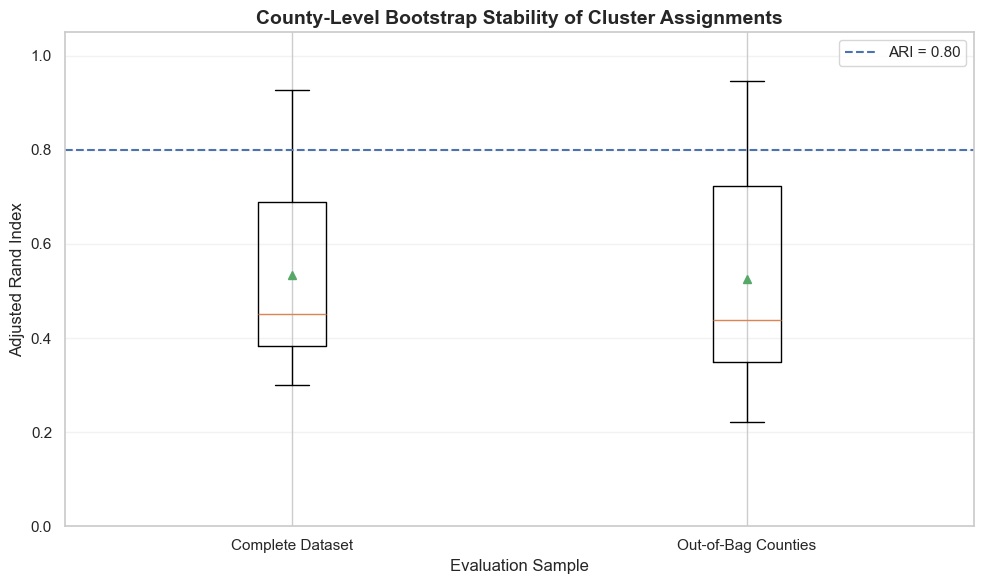

County-level bootstrap stability outputs saved successfully.
Figure saved to: ..\results\figures\vulnerability_clustering\county_level_bootstrap_cluster_stability.png


In [22]:
# ==================================================
# Step 18.3: County-Level Bootstrap Stability
# ==================================================

from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

BOOTSTRAP_REPETITIONS = 100
BOOTSTRAP_RANDOM_SEED = 42
BOOTSTRAP_N_INIT = 50

# ==================================================
# Prepare Original Data and Model Information
# ==================================================

bootstrap_data = clustered_data.copy()

X_bootstrap_full = scaler.transform(
    bootstrap_data[CLUSTERING_FEATURES]
)

original_cluster_labels = (
    bootstrap_data["cluster_id"]
    .astype(int)
    .to_numpy()
)

original_cluster_centers = (
    final_kmeans_model
    .cluster_centers_
    .copy()
)

county_ids = (
    bootstrap_data["STCOFIPS"]
    .drop_duplicates()
    .to_numpy()
)

county_row_indices = {
    county_id: np.flatnonzero(
        bootstrap_data["STCOFIPS"].to_numpy()
        == county_id
    )
    for county_id in county_ids
}

number_of_counties = len(county_ids)
number_of_observations = len(bootstrap_data)

print("County-level bootstrap stability analysis")
print(f"Unique counties: {number_of_counties}")
print(f"County-year observations: {number_of_observations}")
print(f"Bootstrap repetitions: {BOOTSTRAP_REPETITIONS}")

# ==================================================
# Storage Objects
# ==================================================

bootstrap_results = []

# Track how often every observation receives its
# original label when it is evaluated out of bag.
oob_match_counts = np.zeros(
    number_of_observations,
    dtype=float
)

oob_evaluation_counts = np.zeros(
    number_of_observations,
    dtype=float
)

rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_SEED
)

# ==================================================
# Run County-Level Bootstrap
# ==================================================

for repetition in range(
    BOOTSTRAP_REPETITIONS
):

    # Sample complete counties with replacement
    sampled_counties = rng.choice(
        county_ids,
        size=number_of_counties,
        replace=True
    )

    # Include every county-year belonging to each
    # sampled county. Repeated counties receive
    # repeated representation in the bootstrap sample.
    sampled_row_indices = np.concatenate(
        [
            county_row_indices[county_id]
            for county_id in sampled_counties
        ]
    )

    X_bootstrap_sample = (
        X_bootstrap_full[
            sampled_row_indices
        ]
    )

    bootstrap_model = KMeans(
        n_clusters=FINAL_N_CLUSTERS,
        random_state=(
            BOOTSTRAP_RANDOM_SEED
            + repetition
        ),
        n_init=BOOTSTRAP_N_INIT
    )

    bootstrap_model.fit(
        X_bootstrap_sample
    )

    # ==================================================
    # Align Bootstrap Clusters with Original Profiles
    # ==================================================

    centroid_distance_matrix = np.linalg.norm(
        bootstrap_model.cluster_centers_[:, None, :]
        - original_cluster_centers[None, :, :],
        axis=2
    )

    bootstrap_cluster_ids, original_ids = (
        linear_sum_assignment(
            centroid_distance_matrix
        )
    )

    bootstrap_to_original_mapping = {
        int(bootstrap_id): int(original_id)
        for bootstrap_id, original_id
        in zip(
            bootstrap_cluster_ids,
            original_ids
        )
    }

    # Predict assignments for the complete dataset
    raw_full_predictions = (
        bootstrap_model.predict(
            X_bootstrap_full
        )
    )

    aligned_full_predictions = np.array(
        [
            bootstrap_to_original_mapping[
                int(cluster_id)
            ]
            for cluster_id
            in raw_full_predictions
        ]
    )

    # ==================================================
    # Full-Sample Stability
    # ==================================================

    full_sample_ari = adjusted_rand_score(
        original_cluster_labels,
        aligned_full_predictions
    )

    full_assignment_agreement = (
        aligned_full_predictions
        == original_cluster_labels
    ).mean()

    # ==================================================
    # Out-of-Bag Stability
    # ==================================================

    unique_sampled_counties = np.unique(
        sampled_counties
    )

    out_of_bag_counties = np.setdiff1d(
        county_ids,
        unique_sampled_counties
    )

    out_of_bag_mask = (
        bootstrap_data["STCOFIPS"]
        .isin(out_of_bag_counties)
        .to_numpy()
    )

    oob_original_labels = (
        original_cluster_labels[
            out_of_bag_mask
        ]
    )

    oob_predicted_labels = (
        aligned_full_predictions[
            out_of_bag_mask
        ]
    )

    if (
        out_of_bag_mask.sum() > 1
        and np.unique(
            oob_original_labels
        ).size > 1
        and np.unique(
            oob_predicted_labels
        ).size > 1
    ):
        oob_ari = adjusted_rand_score(
            oob_original_labels,
            oob_predicted_labels
        )
    else:
        oob_ari = np.nan

    oob_assignment_agreement = (
        (
            oob_original_labels
            == oob_predicted_labels
        ).mean()
        if out_of_bag_mask.sum() > 0
        else np.nan
    )

    # Track observation-level out-of-bag stability
    oob_match_counts[out_of_bag_mask] += (
        oob_original_labels
        == oob_predicted_labels
    ).astype(float)

    oob_evaluation_counts[out_of_bag_mask] += 1

    # ==================================================
    # Align Bootstrap Centroids
    # ==================================================

    aligned_bootstrap_centers = np.empty_like(
        original_cluster_centers
    )

    for (
        bootstrap_cluster_id,
        original_cluster_id
    ) in bootstrap_to_original_mapping.items():

        aligned_bootstrap_centers[
            original_cluster_id
        ] = (
            bootstrap_model
            .cluster_centers_[
                bootstrap_cluster_id
            ]
        )

    centroid_distances = np.linalg.norm(
        aligned_bootstrap_centers
        - original_cluster_centers,
        axis=1
    )

    repetition_result = {
        "bootstrap_repetition":
            repetition + 1,
        "unique_sampled_counties":
            len(unique_sampled_counties),
        "out_of_bag_counties":
            len(out_of_bag_counties),
        "full_sample_ari":
            full_sample_ari,
        "oob_ari":
            oob_ari,
        "full_assignment_agreement_pct":
            full_assignment_agreement * 100,
        "oob_assignment_agreement_pct":
            oob_assignment_agreement * 100,
        "mean_centroid_distance":
            centroid_distances.mean(),
        "maximum_centroid_distance":
            centroid_distances.max()
    }

    for cluster_id in range(
        FINAL_N_CLUSTERS
    ):
        repetition_result[
            f"centroid_distance_cluster_{cluster_id}"
        ] = centroid_distances[
            cluster_id
        ]

    bootstrap_results.append(
        repetition_result
    )

bootstrap_stability_results = pd.DataFrame(
    bootstrap_results
)

print(
    "\nCounty-level bootstrap repetitions completed."
)

# ==================================================
# Overall Bootstrap Summary
# ==================================================

summary_metrics = [
    "full_sample_ari",
    "oob_ari",
    "full_assignment_agreement_pct",
    "oob_assignment_agreement_pct",
    "mean_centroid_distance",
    "maximum_centroid_distance"
]

bootstrap_stability_summary = (
    bootstrap_stability_results[
        summary_metrics
    ]
    .describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95
        ]
    )
    .T
    .rename(
        columns={
            "count": "valid_repetitions",
            "mean": "mean",
            "std": "standard_deviation",
            "min": "minimum",
            "5%": "p05",
            "25%": "p25",
            "50%": "median",
            "75%": "p75",
            "95%": "p95",
            "max": "maximum"
        }
    )
)

print("\nOverall bootstrap-stability summary")
display(
    bootstrap_stability_summary.round(4)
)

# ==================================================
# Observation-Level Out-of-Bag Stability
# ==================================================

observation_oob_stability = np.divide(
    oob_match_counts,
    oob_evaluation_counts,
    out=np.full(
        number_of_observations,
        np.nan,
        dtype=float
    ),
    where=oob_evaluation_counts > 0
)

bootstrap_assignment_stability = (
    bootstrap_data[
        [
            "STCOFIPS",
            "RegionName",
            "Year",
            "cluster_id",
            "cluster_name"
        ]
    ]
    .copy()
)

bootstrap_assignment_stability[
    "oob_evaluations"
] = oob_evaluation_counts

bootstrap_assignment_stability[
    "oob_assignment_stability_pct"
] = (
    observation_oob_stability
    * 100
)

# ==================================================
# Profile-Level Stability Summary
# ==================================================

profile_stability_rows = []

for cluster_id in range(
    FINAL_N_CLUSTERS
):

    cluster_mask = (
        bootstrap_assignment_stability[
            "cluster_id"
        ]
        == cluster_id
    )

    cluster_stability_values = (
        bootstrap_assignment_stability.loc[
            cluster_mask,
            "oob_assignment_stability_pct"
        ]
        .dropna()
    )

    centroid_distance_column = (
        f"centroid_distance_cluster_{cluster_id}"
    )

    profile_stability_rows.append({
        "cluster_id":
            cluster_id,
        "cluster_name":
            CLUSTER_NAMES[cluster_id],
        "county_year_observations":
            int(cluster_mask.sum()),
        "mean_oob_assignment_stability_pct":
            cluster_stability_values.mean(),
        "median_oob_assignment_stability_pct":
            cluster_stability_values.median(),
        "minimum_oob_assignment_stability_pct":
            cluster_stability_values.min(),
        "mean_centroid_distance":
            bootstrap_stability_results[
                centroid_distance_column
            ].mean(),
        "maximum_centroid_distance":
            bootstrap_stability_results[
                centroid_distance_column
            ].max()
    })

profile_bootstrap_stability = pd.DataFrame(
    profile_stability_rows
)

print("\nBootstrap stability by vulnerability profile")
display(
    profile_bootstrap_stability.round(4)
)

# ==================================================
# Additional Stability Indicators
# ==================================================

bootstrap_indicator_table = pd.DataFrame({
    "indicator": [
        "Bootstrap repetitions",
        "Mean full-sample ARI",
        "Minimum full-sample ARI",
        "Mean out-of-bag ARI",
        "Minimum out-of-bag ARI",
        "Mean full assignment agreement (%)",
        "Mean out-of-bag assignment agreement (%)",
        "Repetitions with full-sample ARI ≥ 0.80 (%)",
        "Repetitions with out-of-bag ARI ≥ 0.80 (%)"
    ],
    "value": [
        BOOTSTRAP_REPETITIONS,
        bootstrap_stability_results[
            "full_sample_ari"
        ].mean(),
        bootstrap_stability_results[
            "full_sample_ari"
        ].min(),
        bootstrap_stability_results[
            "oob_ari"
        ].mean(),
        bootstrap_stability_results[
            "oob_ari"
        ].min(),
        bootstrap_stability_results[
            "full_assignment_agreement_pct"
        ].mean(),
        bootstrap_stability_results[
            "oob_assignment_agreement_pct"
        ].mean(),
        (
            bootstrap_stability_results[
                "full_sample_ari"
            ]
            >= 0.80
        ).mean() * 100,
        (
            bootstrap_stability_results[
                "oob_ari"
            ]
            >= 0.80
        ).mean() * 100
    ]
})

print("\nKey bootstrap-stability indicators")
display(
    bootstrap_indicator_table.round(4)
)

# ==================================================
# Visualize ARI Distribution
# ==================================================

valid_oob_ari = (
    bootstrap_stability_results[
        "oob_ari"
    ]
    .dropna()
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.boxplot(
    [
        bootstrap_stability_results[
            "full_sample_ari"
        ],
        valid_oob_ari
    ],
    labels=[
        "Complete Dataset",
        "Out-of-Bag Counties"
    ],
    showmeans=True
)

ax.axhline(
    0.80,
    linestyle="--",
    linewidth=1.5,
    label="ARI = 0.80"
)

ax.set_title(
    "County-Level Bootstrap Stability of Cluster Assignments",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Evaluation Sample")
ax.set_ylabel("Adjusted Rand Index")
ax.set_ylim(0, 1.05)
ax.grid(
    axis="y",
    alpha=0.25
)
ax.legend()

plt.tight_layout()

bootstrap_stability_figure_path = (
    RESULTS_FIGURES
    / "county_level_bootstrap_cluster_stability.png"
)

plt.savefig(
    bootstrap_stability_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==================================================
# Save Bootstrap Stability Outputs
# ==================================================

bootstrap_stability_results.to_csv(
    RESULTS_TABLES
    / "county_level_bootstrap_results.csv",
    index=False
)

bootstrap_stability_summary.to_csv(
    RESULTS_TABLES
    / "county_level_bootstrap_summary.csv"
)

profile_bootstrap_stability.to_csv(
    RESULTS_TABLES
    / "bootstrap_stability_by_profile.csv",
    index=False
)

bootstrap_indicator_table.to_csv(
    RESULTS_TABLES
    / "bootstrap_stability_key_indicators.csv",
    index=False
)

bootstrap_assignment_stability.to_csv(
    RESULTS_TABLES
    / "observation_level_oob_assignment_stability.csv",
    index=False
)

print(
    "County-level bootstrap stability outputs saved successfully."
)

print(
    f"Figure saved to: "
    f"{bootstrap_stability_figure_path}"
)

### Interpretation

The county-level bootstrap analysis indicates moderate stability of the four-profile clustering solution. Across 100 county-resampled models, the mean Adjusted Rand Index was 0.5338 for the complete dataset and 0.5251 for out-of-bag counties. Mean assignment agreement was 69.24% for the complete dataset and 68.27% for out-of-bag observations. The similarity between the complete-sample and out-of-bag results suggests that the fitted bootstrap models did not reproduce the original assignments only for counties represented during model fitting.

Stability differed across the four vulnerability profiles. Disaster-Loss Growth Pressure and Socioeconomic Resilience Stress were the most reproducible, with mean out-of-bag assignment stability of 77.93% and 77.80%, respectively. Lower-Stress Resilient showed moderate stability at 60.64%, while High-Exposure Latent Risk was the most sample-sensitive profile at 54.09%.

These results support the use of the four-cluster solution as an interpretable exploratory typology rather than as a set of rigid and perfectly separated natural classes. The weaker stability of High-Exposure Latent Risk is consistent with the recent county-level robustness analysis and suggests that this profile may overlap with, or transition toward, Disaster-Loss Growth Pressure as realized disasters and insurance losses accumulate.

## 19. Interpret and Visualize Cluster Separation with PCA

Principal Component Analysis is used to project the seven standardized clustering dimensions into two components for visual interpretation.

In addition to reporting the variance explained by PC1 and PC2, the component loadings are examined to identify which vulnerability dimensions drive movement along each axis.

The final figure includes:

- county-year observations coloured by vulnerability profile;
- directly labelled cluster centroids;
- 90% covariance ellipses showing the central distribution of each profile;
- explained variance in the axis labels.

The PCA figure is used as a two-dimensional summary of the clustering structure. Because the first two components do not retain all variation in the original seven-dimensional feature space, overlap in the PCA plot does not necessarily mean that the clusters are identical.

PCA completed successfully.
PC1 explained variance: 37.83%
PC2 explained variance: 17.09%
Total variance explained by PC1 and PC2: 54.92%


,principal_component,explained_variance_pct
0,PC1,37.8340
1,PC2,17.0863



PCA loadings


,PC1,PC2
affordability_stress_score,0.4824,0.2542
climate_exposure_score,0.4299,0.3170
disaster_history_score,0.2939,-0.0730
socioeconomic_vulnerability_score,-0.3644,0.5567
resilience_adjustment_score,-0.2511,0.6593
insurance_loss_stress_score,0.4910,0.1404
spatial_spillover_score,0.2431,0.2552


Dimensions contributing most strongly to PC1


,PC1,PC1_absolute
insurance_loss_stress_score,0.4910,0.4910
affordability_stress_score,0.4824,0.4824
climate_exposure_score,0.4299,0.4299
socioeconomic_vulnerability_score,-0.3644,0.3644
disaster_history_score,0.2939,0.2939
resilience_adjustment_score,-0.2511,0.2511
spatial_spillover_score,0.2431,0.2431


Dimensions contributing most strongly to PC2


,PC2,PC2_absolute
resilience_adjustment_score,0.6593,0.6593
socioeconomic_vulnerability_score,0.5567,0.5567
climate_exposure_score,0.3170,0.3170
spatial_spillover_score,0.2552,0.2552
affordability_stress_score,0.2542,0.2542
insurance_loss_stress_score,0.1404,0.1404
disaster_history_score,-0.0730,0.0730



Cluster centroids in PCA space


,cluster_id,cluster_name,PC1,PC2
0,0,Lower-Stress Resilient Profile,0.4514,-1.6465
1,1,Disaster-Loss Growth Pressure,1.8495,0.1894
2,2,High-Exposure Latent Risk,0.6593,0.6194
3,3,Socioeconomic Resilience Stress,-1.7449,0.1963


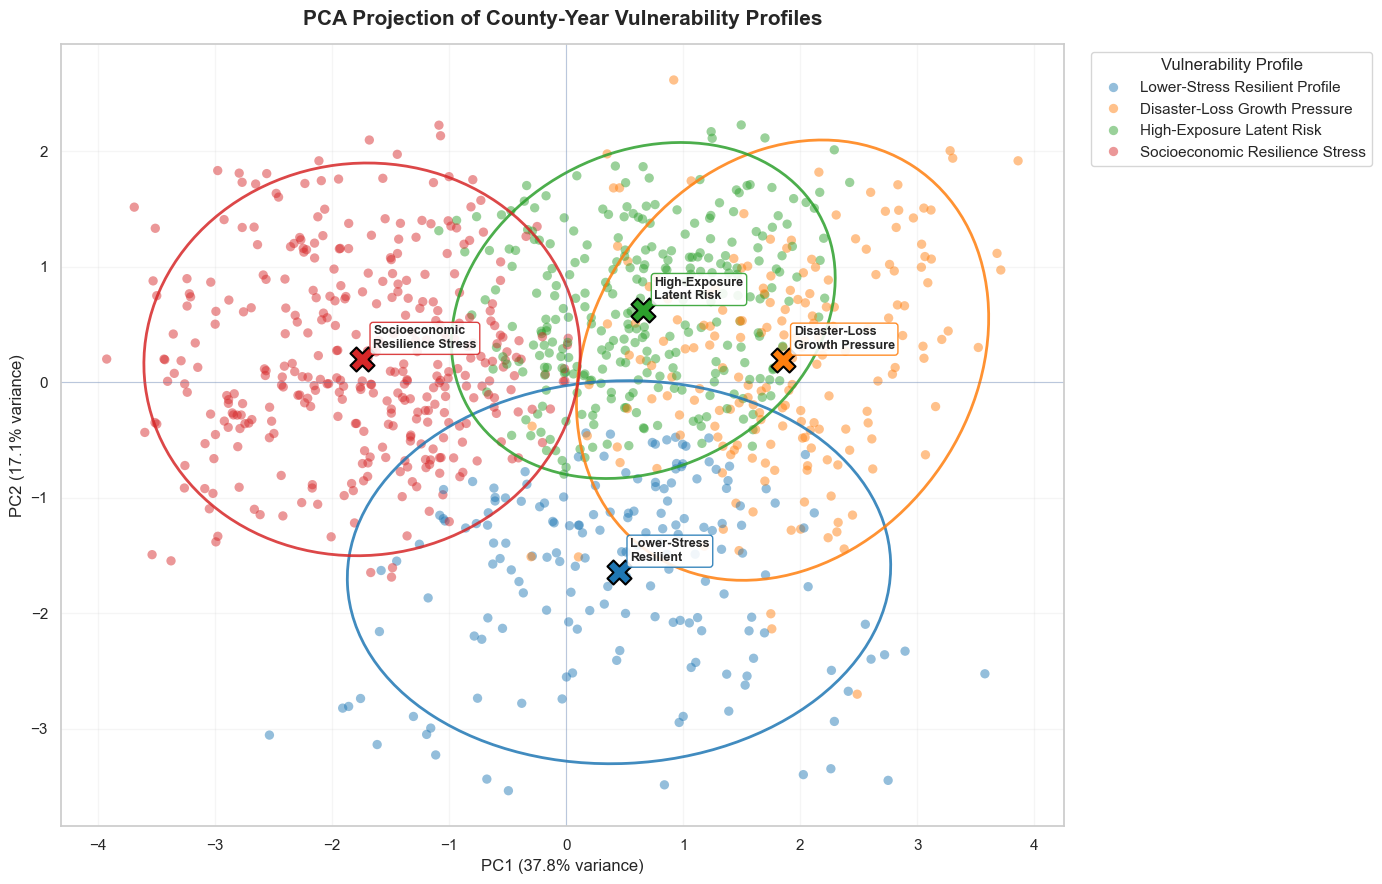

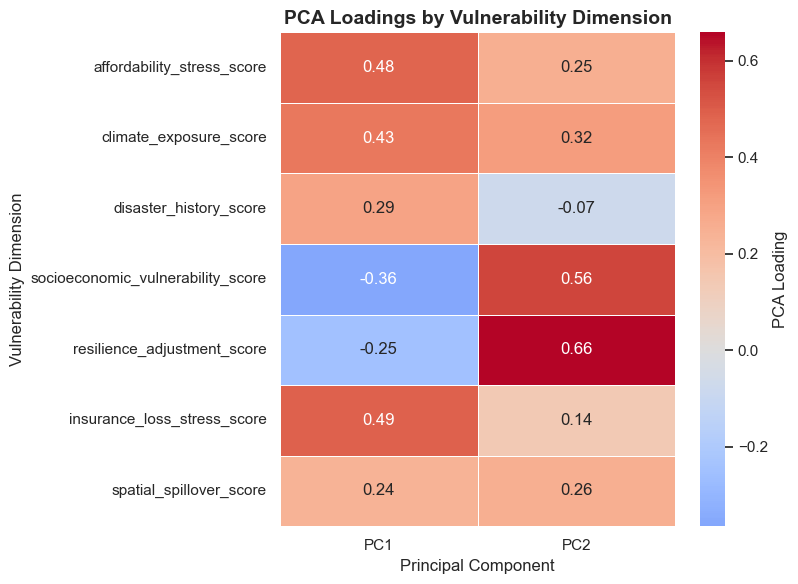

Improved PCA outputs saved successfully.
PCA cluster figure saved to: ..\results\figures\vulnerability_clustering\pca_vulnerability_profiles_with_ellipses.png
PCA loading figure saved to: ..\results\figures\vulnerability_clustering\pca_vulnerability_dimension_loadings.png


In [23]:
# ==================================================
# Step 19: Interpret and Visualize Clusters with PCA
# ==================================================

from matplotlib.patches import Ellipse
from scipy.stats import chi2
import textwrap

# ==================================================
# Fit Two-Component PCA
# ==================================================

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

pca_coordinates = pca.fit_transform(
    X_scaled
)

clustered_data["PC1"] = pca_coordinates[:, 0]
clustered_data["PC2"] = pca_coordinates[:, 1]

explained_variance_table = pd.DataFrame({
    "principal_component": ["PC1", "PC2"],
    "explained_variance_pct": (
        pca.explained_variance_ratio_ * 100
    )
})

total_explained_variance = (
    pca.explained_variance_ratio_.sum()
    * 100
)

print("PCA completed successfully.")

print(
    f"PC1 explained variance: "
    f"{explained_variance_table.loc[0, 'explained_variance_pct']:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{explained_variance_table.loc[1, 'explained_variance_pct']:.2f}%"
)

print(
    f"Total variance explained by PC1 and PC2: "
    f"{total_explained_variance:.2f}%"
)

display(
    explained_variance_table.round(4)
)

# ==================================================
# Calculate PCA Loadings
# ==================================================
#
# Each loading shows how strongly one clustering
# dimension contributes to a principal component.
# Positive and negative signs indicate direction,
# while larger absolute values indicate greater
# influence.
# ==================================================

pca_loadings_table = pd.DataFrame(
    pca.components_.T,
    index=CLUSTERING_FEATURES,
    columns=["PC1", "PC2"]
)

pca_loadings_table["PC1_absolute"] = (
    pca_loadings_table["PC1"].abs()
)

pca_loadings_table["PC2_absolute"] = (
    pca_loadings_table["PC2"].abs()
)

print("\nPCA loadings")
display(
    pca_loadings_table[
        ["PC1", "PC2"]
    ].round(4)
)

print("Dimensions contributing most strongly to PC1")
display(
    pca_loadings_table[
        ["PC1", "PC1_absolute"]
    ]
    .sort_values(
        "PC1_absolute",
        ascending=False
    )
    .round(4)
)

print("Dimensions contributing most strongly to PC2")
display(
    pca_loadings_table[
        ["PC2", "PC2_absolute"]
    ]
    .sort_values(
        "PC2_absolute",
        ascending=False
    )
    .round(4)
)

# ==================================================
# Transform Cluster Centroids into PCA Space
# ==================================================

pca_cluster_centers = pca.transform(
    final_kmeans_model.cluster_centers_
)

pca_centers_table = pd.DataFrame({
    "cluster_id": range(FINAL_N_CLUSTERS),
    "cluster_name": [
        CLUSTER_NAMES[cluster_id]
        for cluster_id
        in range(FINAL_N_CLUSTERS)
    ],
    "PC1": pca_cluster_centers[:, 0],
    "PC2": pca_cluster_centers[:, 1]
})

print("\nCluster centroids in PCA space")
display(
    pca_centers_table.round(4)
)

# ==================================================
# Function for Confidence Ellipses
# ==================================================

def add_confidence_ellipse(
    axis,
    x_values,
    y_values,
    edge_color,
    confidence_level=0.90,
    line_width=2.0,
    transparency=0.85
):
    """
    Draw a covariance-based confidence ellipse.

    Parameters
    ----------
    axis:
        Matplotlib axis.
    x_values, y_values:
        PCA coordinates for one cluster.
    edge_color:
        Colour used for the ellipse outline.
    confidence_level:
        Proportion represented by the ellipse.
    """

    x_values = np.asarray(x_values)
    y_values = np.asarray(y_values)

    if len(x_values) < 3:
        return

    covariance_matrix = np.cov(
        x_values,
        y_values
    )

    eigenvalues, eigenvectors = np.linalg.eigh(
        covariance_matrix
    )

    order = eigenvalues.argsort()[::-1]

    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0]
        )
    )

    confidence_scale = np.sqrt(
        chi2.ppf(
            confidence_level,
            df=2
        )
    )

    width = (
        2
        * confidence_scale
        * np.sqrt(eigenvalues[0])
    )

    height = (
        2
        * confidence_scale
        * np.sqrt(eigenvalues[1])
    )

    ellipse = Ellipse(
        xy=(
            x_values.mean(),
            y_values.mean()
        ),
        width=width,
        height=height,
        angle=angle,
        facecolor="none",
        edgecolor=edge_color,
        linewidth=line_width,
        alpha=transparency
    )

    axis.add_patch(ellipse)

# ==================================================
# Create Consistent Profile Colours
# ==================================================

cluster_name_order = [
    CLUSTER_NAMES[cluster_id]
    for cluster_id
    in range(FINAL_N_CLUSTERS)
]

cluster_palette_values = sns.color_palette(
    "tab10",
    n_colors=FINAL_N_CLUSTERS
)

cluster_palette = {
    cluster_name: cluster_palette_values[index]
    for index, cluster_name
    in enumerate(cluster_name_order)
}

# Shorter labels for centroid annotations
centroid_labels = {
    "Lower-Stress Resilient Profile":
        "Lower-Stress\nResilient",

    "Disaster-Loss Growth Pressure":
        "Disaster-Loss\nGrowth Pressure",

    "High-Exposure Latent Risk":
        "High-Exposure\nLatent Risk",

    "Socioeconomic Resilience Stress":
        "Socioeconomic\nResilience Stress"
}

# ==================================================
# Improved PCA Cluster Plot
# ==================================================

fig, ax = plt.subplots(
    figsize=(14, 9)
)

sns.scatterplot(
    data=clustered_data,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    hue_order=cluster_name_order,
    palette=cluster_palette,
    alpha=0.48,
    s=45,
    linewidth=0,
    ax=ax
)

# Add one confidence ellipse per profile
for cluster_name in cluster_name_order:

    cluster_points = clustered_data[
        clustered_data["cluster_name"]
        == cluster_name
    ]

    add_confidence_ellipse(
        axis=ax,
        x_values=cluster_points["PC1"],
        y_values=cluster_points["PC2"],
        edge_color=cluster_palette[
            cluster_name
        ],
        confidence_level=0.90
    )

# Plot cluster centroids
for _, centroid_row in pca_centers_table.iterrows():

    cluster_name = centroid_row["cluster_name"]

    ax.scatter(
        centroid_row["PC1"],
        centroid_row["PC2"],
        marker="X",
        s=300,
        color=cluster_palette[
            cluster_name
        ],
        edgecolor="black",
        linewidth=1.5,
        zorder=5
    )

    ax.annotate(
        centroid_labels.get(
            cluster_name,
            "\n".join(
                textwrap.wrap(
                    cluster_name,
                    width=20
                )
            )
        ),
        xy=(
            centroid_row["PC1"],
            centroid_row["PC2"]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": cluster_palette[
                cluster_name
            ],
            "alpha": 0.88
        },
        zorder=6
    )

ax.axhline(
    0,
    linewidth=0.8,
    alpha=0.35
)

ax.axvline(
    0,
    linewidth=0.8,
    alpha=0.35
)

ax.set_title(
    "PCA Projection of County-Year Vulnerability Profiles",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel(
    f"PC1 "
    f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

ax.set_ylabel(
    f"PC2 "
    f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

ax.legend(
    title="Vulnerability Profile",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

ax.grid(
    alpha=0.18
)

plt.tight_layout()

improved_pca_figure_path = (
    RESULTS_FIGURES
    / "pca_vulnerability_profiles_with_ellipses.png"
)

plt.savefig(
    improved_pca_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==================================================
# PCA Loading Heatmap
# ==================================================

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    pca_loadings_table[
        ["PC1", "PC2"]
    ],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={
        "label": "PCA Loading"
    }
)

plt.title(
    "PCA Loadings by Vulnerability Dimension",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Principal Component")
plt.ylabel("Vulnerability Dimension")

plt.tight_layout()

pca_loadings_figure_path = (
    RESULTS_FIGURES
    / "pca_vulnerability_dimension_loadings.png"
)

plt.savefig(
    pca_loadings_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==================================================
# Save PCA Outputs
# ==================================================

explained_variance_table.to_csv(
    RESULTS_TABLES
    / "pca_explained_variance.csv",
    index=False
)

pca_loadings_table.to_csv(
    RESULTS_TABLES
    / "pca_component_loadings.csv"
)

pca_centers_table.to_csv(
    RESULTS_TABLES
    / "pca_cluster_centroids.csv",
    index=False
)

print(
    "Improved PCA outputs saved successfully."
)

print(
    f"PCA cluster figure saved to: "
    f"{improved_pca_figure_path}"
)

print(
    f"PCA loading figure saved to: "
    f"{pca_loadings_figure_path}"
)

### Interpretation

The first two principal components explain 54.92% of the total variation in the seven clustering dimensions. PC1 explains 37.83% and is driven primarily by insurance-loss stress, affordability pressure, climate exposure, and disaster history. It can therefore be interpreted as a physical, financial, and housing-pressure dimension.

PC2 explains 17.09% and is driven most strongly by resilience-adjustment stress and socioeconomic vulnerability. It represents a socioeconomic vulnerability and resilience-stress dimension. Higher values indicate greater social sensitivity and weaker resilience capacity, while lower values indicate lower socioeconomic stress and stronger resilience.

The Disaster-Loss Growth Pressure centroid is positioned furthest along the positive PC1 direction, confirming that this profile is primarily characterized by insurance losses, affordability pressure, climate exposure, and realized disaster experience. High-Exposure Latent Risk occupies a more moderate PC1 position and a higher PC2 position, reflecting a combination of physical exposure, spatial pressure, and some socioeconomic or resilience stress without the same level of realized disaster-loss pressure.

The Lower-Stress Resilient Profile has the lowest PC2 position, consistent with lower socioeconomic vulnerability and stronger resilience. Socioeconomic Resilience Stress occupies the negative PC1 side of the projection but remains positive on PC2, confirming that it is driven more by social vulnerability and reduced resilience than by the highest climate exposure or insurance-loss burden.

The confidence ellipses overlap, indicating that vulnerability exists on a continuum rather than forming four perfectly isolated groups. However, the separated cluster centroids demonstrate that the four profiles represent distinct average combinations of physical exposure, financial loss, affordability, socioeconomic sensitivity, and resilience.

## 20. Summarize County Cluster Membership

Identify each county’s latest-year cluster and dominant cluster across the most recent five years.

In [24]:
# ==================================================
# Step 20: Summarize County Cluster Membership
# ==================================================

latest_year = clustered_data["Year"].max()
recent_start_year = latest_year - 4

recent_cluster_data = (
    clustered_data[
        clustered_data["Year"].between(
            recent_start_year,
            latest_year
        )
    ]
    .sort_values(
        ["STCOFIPS", "Year"]
    )
    .copy()
)

# ==================================================
# Latest-Year Cluster
# ==================================================

latest_year_membership = (
    clustered_data[
        clustered_data["Year"] == latest_year
    ][
        [
            "STCOFIPS",
            "RegionName",
            "cluster_id",
            "cluster_name",
            "climate_housing_vulnerability_score",
            "vulnerability_class",
            "annual_price_growth_pct"
        ]
    ]
    .rename(
        columns={
            "cluster_id": "latest_cluster_id",
            "cluster_name": "latest_cluster_name",
            "climate_housing_vulnerability_score":
                "latest_vulnerability_score",
            "vulnerability_class":
                "latest_vulnerability_class",
            "annual_price_growth_pct":
                "latest_annual_growth_pct"
        }
    )
)

# ==================================================
# Dominant Recent Cluster
# ==================================================

recent_cluster_counts = (
    recent_cluster_data
    .groupby(
        [
            "STCOFIPS",
            "RegionName",
            "cluster_id",
            "cluster_name"
        ]
    )
    .size()
    .reset_index(name="years_in_cluster")
)

recent_cluster_totals = (
    recent_cluster_data
    .groupby(
        [
            "STCOFIPS",
            "RegionName"
        ]
    )
    .size()
    .reset_index(name="recent_years_observed")
)

recent_cluster_counts = recent_cluster_counts.merge(
    recent_cluster_totals,
    on=["STCOFIPS", "RegionName"],
    how="left"
)

recent_cluster_counts["recent_cluster_share_pct"] = (
    recent_cluster_counts["years_in_cluster"]
    / recent_cluster_counts["recent_years_observed"]
    * 100
)

dominant_recent_cluster = (
    recent_cluster_counts
    .sort_values(
        [
            "STCOFIPS",
            "years_in_cluster",
            "cluster_id"
        ],
        ascending=[True, False, True]
    )
    .drop_duplicates("STCOFIPS")
    .rename(
        columns={
            "cluster_id": "dominant_recent_cluster_id",
            "cluster_name": "dominant_recent_cluster_name"
        }
    )
)

# ==================================================
# Recent Cluster Transitions
# ==================================================

recent_transition_summary = (
    recent_cluster_data
    .groupby("STCOFIPS")["cluster_id"]
    .apply(
        lambda values:
        values.ne(values.shift()).sum() - 1
    )
    .clip(lower=0)
    .rename("recent_cluster_transitions")
    .reset_index()
)

# ==================================================
# Final County Membership Table
# ==================================================

county_cluster_membership = (
    latest_year_membership
    .merge(
        dominant_recent_cluster[
            [
                "STCOFIPS",
                "dominant_recent_cluster_id",
                "dominant_recent_cluster_name",
                "years_in_cluster",
                "recent_years_observed",
                "recent_cluster_share_pct"
            ]
        ],
        on="STCOFIPS",
        how="left"
    )
    .merge(
        recent_transition_summary,
        on="STCOFIPS",
        how="left"
    )
    .sort_values(
        [
            "latest_cluster_id",
            "RegionName"
        ]
    )
)

county_cluster_membership[
    "recent_cluster_share_pct"
] = county_cluster_membership[
    "recent_cluster_share_pct"
].round(2)

print("County cluster membership summarized successfully.")
print(
    f"Recent period: {recent_start_year}–{latest_year}"
)
print(
    f"Counties summarized: "
    f"{county_cluster_membership['STCOFIPS'].nunique()}"
)

display(
    county_cluster_membership.head(15)
)

county_cluster_membership.to_csv(
    RESULTS_TABLES / "county_cluster_membership.csv",
    index=False
)

print(
    "County membership table saved to: "
    f"{RESULTS_TABLES / 'county_cluster_membership.csv'}"
)

County cluster membership summarized successfully.
Recent period: 2021–2025
Counties summarized: 67


,STCOFIPS,RegionName,latest_cluster_id,latest_cluster_name,latest_vulnerability_score,latest_vulnerability_class,latest_annual_growth_pct,dominant_recent_cluster_id,dominant_recent_cluster_name,years_in_cluster,recent_years_observed,recent_cluster_share_pct,recent_cluster_transitions
0,12001,Alachua County,0,Lower-Stress Resilient Profile,0.3564,Low,-1.5900,0,Lower-Stress Resilient Profile,3,5,60.0000,4
1,12003,Baker County,0,Lower-Stress Resilient Profile,0.2720,Low,0.9194,0,Lower-Stress Resilient Profile,5,5,100.0000,0
4,12009,Brevard County,0,Lower-Stress Resilient Profile,0.4965,Medium,-3.6820,1,Disaster-Loss Growth Pressure,3,5,60.0000,2
9,12019,Clay County,0,Lower-Stress Resilient Profile,0.4119,Low,-2.0607,0,Lower-Stress Resilient Profile,3,5,60.0000,4
14,12031,Duval County,0,Lower-Stress Resilient Profile,0.4586,Medium,-3.2685,1,Disaster-Loss Growth Pressure,3,5,60.0000,2
16,12035,Flagler County,0,Lower-Stress Resilient Profile,0.4460,Medium,-4.7733,1,Disaster-Loss Growth Pressure,3,5,60.0000,2
17,12037,Franklin County,0,Lower-Stress Resilient Profile,0.4446,Medium,-4.6156,1,Disaster-Loss Growth Pressure,4,5,80.0000,1
21,12045,Gulf County,0,Lower-Stress Resilient Profile,0.4205,Low,-3.4721,1,Disaster-Loss Growth Pressure,4,5,80.0000,1
29,12061,Indian River County,0,Lower-Stress Resilient Profile,0.4585,Medium,-4.6872,0,Lower-Stress Resilient Profile,3,5,60.0000,4
33,12069,Lake County,0,Lower-Stress Resilient Profile,0.4585,Medium,-2.1511,1,Disaster-Loss Growth Pressure,3,5,60.0000,2


County membership table saved to: ..\results\tables\vulnerability_clustering\county_cluster_membership.csv


## Representative Counties for Each Vulnerability Profile

To make the cluster profiles more interpretable, representative county-year observations are identified using their Euclidean distance from the assigned K-Means centroid.

Observations closest to a centroid have vulnerability characteristics that most closely match the average fingerprint of that profile. To avoid repeatedly selecting different years from the same county, the final table retains the five closest unique counties for each cluster.

The analysis also identifies:

- representative counties in the latest study year;
- each county’s dominant profile during 2021–2025;
- the persistence of that dominant profile across the recent five-year period.

These results connect the statistical cluster profiles to identifiable Florida county examples.

In [25]:
# ==================================================
# Identify Representative Counties for Each Profile
# ==================================================

REPRESENTATIVE_COUNTIES_PER_PROFILE = 5
RECENT_PROFILE_START_YEAR = 2021
RECENT_PROFILE_END_YEAR = 2025

# ==================================================
# Calculate Distance to Assigned Cluster Centroid
# ==================================================

X_profile_scaled = scaler.transform(
    clustered_data[CLUSTERING_FEATURES]
)

assigned_cluster_ids = (
    clustered_data["cluster_id"]
    .astype(int)
    .to_numpy()
)

assigned_centroids = (
    final_kmeans_model.cluster_centers_[
        assigned_cluster_ids
    ]
)

distance_to_assigned_centroid = np.linalg.norm(
    X_profile_scaled - assigned_centroids,
    axis=1
)

# Include available housing and vulnerability outcomes
possible_context_columns = [
    "annual_price_growth_pct",
    "avg_annual_housing_price",
    "annual_price_volatility",
    "housing_pressure_score",
    "climate_housing_vulnerability_score",
    "vulnerability_class"
]

context_columns = [
    column
    for column in possible_context_columns
    if column in clustered_data.columns
]

representative_columns = list(
    dict.fromkeys(
        [
            "STCOFIPS",
            "RegionName",
            "Year",
            "cluster_id",
            "cluster_name"
        ]
        + CLUSTERING_FEATURES
        + context_columns
    )
)

cluster_representative_data = (
    clustered_data[
        representative_columns
    ]
    .copy()
)

cluster_representative_data[
    "distance_to_cluster_centroid"
] = distance_to_assigned_centroid

# ==================================================
# Five Closest Unique Counties Per Cluster
# ==================================================
#
# First retain the closest observation for each county
# within each cluster. Then select the five closest
# unique counties for every profile.
# ==================================================

representative_county_years = (
    cluster_representative_data
    .sort_values(
        [
            "cluster_id",
            "distance_to_cluster_centroid",
            "RegionName",
            "Year"
        ]
    )
    .drop_duplicates(
        subset=[
            "cluster_id",
            "STCOFIPS"
        ],
        keep="first"
    )
    .groupby(
        "cluster_id",
        group_keys=False
    )
    .head(
        REPRESENTATIVE_COUNTIES_PER_PROFILE
    )
    .reset_index(drop=True)
)

# Rank representatives within each cluster
representative_county_years[
    "representative_rank"
] = (
    representative_county_years
    .groupby("cluster_id")
    .cumcount()
    + 1
)

# ==================================================
# Latest-Year Cluster Membership
# ==================================================

latest_profile_year = int(
    clustered_data["Year"].max()
)

latest_year_cluster_members = (
    cluster_representative_data[
        cluster_representative_data["Year"]
        == latest_profile_year
    ]
    .copy()
)

latest_year_cluster_counts = (
    latest_year_cluster_members
    .groupby(
        [
            "cluster_id",
            "cluster_name"
        ],
        as_index=False
    )
    .agg(
        counties_in_latest_year=(
            "STCOFIPS",
            "nunique"
        )
    )
    .sort_values("cluster_id")
)

# Select five latest-year examples closest to each centroid
latest_year_representatives = (
    latest_year_cluster_members
    .sort_values(
        [
            "cluster_id",
            "distance_to_cluster_centroid",
            "RegionName"
        ]
    )
    .groupby(
        "cluster_id",
        group_keys=False
    )
    .head(
        REPRESENTATIVE_COUNTIES_PER_PROFILE
    )
    .reset_index(drop=True)
)

latest_year_representatives[
    "latest_year_rank"
] = (
    latest_year_representatives
    .groupby("cluster_id")
    .cumcount()
    + 1
)

# ==================================================
# Dominant Recent Profile for Every County
# ==================================================

recent_profile_data = (
    cluster_representative_data[
        cluster_representative_data["Year"].between(
            RECENT_PROFILE_START_YEAR,
            RECENT_PROFILE_END_YEAR
        )
    ]
    .copy()
)

recent_county_year_totals = (
    recent_profile_data
    .groupby(
        [
            "STCOFIPS",
            "RegionName"
        ],
        as_index=False
    )
    .agg(
        recent_years_observed=(
            "Year",
            "nunique"
        )
    )
)

recent_profile_membership = (
    recent_profile_data
    .groupby(
        [
            "STCOFIPS",
            "RegionName",
            "cluster_id",
            "cluster_name"
        ],
        as_index=False
    )
    .agg(
        years_in_profile=(
            "Year",
            "nunique"
        ),
        average_centroid_distance=(
            "distance_to_cluster_centroid",
            "mean"
        )
    )
    .merge(
        recent_county_year_totals,
        on=[
            "STCOFIPS",
            "RegionName"
        ],
        how="left"
    )
)

recent_profile_membership[
    "profile_persistence_pct"
] = (
    recent_profile_membership[
        "years_in_profile"
    ]
    / recent_profile_membership[
        "recent_years_observed"
    ]
    * 100
)

# Choose the most frequent recent profile.
# Ties are resolved using the smaller average
# distance to the relevant cluster centroid.
dominant_recent_profiles = (
    recent_profile_membership
    .sort_values(
        [
            "STCOFIPS",
            "years_in_profile",
            "average_centroid_distance",
            "cluster_id"
        ],
        ascending=[
            True,
            False,
            True,
            True
        ]
    )
    .drop_duplicates(
        subset="STCOFIPS",
        keep="first"
    )
    .rename(
        columns={
            "cluster_id":
                "dominant_recent_cluster_id",
            "cluster_name":
                "dominant_recent_cluster_name",
            "years_in_profile":
                "years_in_dominant_profile",
            "profile_persistence_pct":
                "dominant_profile_persistence_pct"
        }
    )
    .reset_index(drop=True)
)

# ==================================================
# Recent Dominant-Profile Summary
# ==================================================

recent_dominant_profile_summary = (
    dominant_recent_profiles
    .groupby(
        [
            "dominant_recent_cluster_id",
            "dominant_recent_cluster_name"
        ],
        as_index=False
    )
    .agg(
        counties=(
            "STCOFIPS",
            "nunique"
        ),
        mean_persistence_pct=(
            "dominant_profile_persistence_pct",
            "mean"
        ),
        median_persistence_pct=(
            "dominant_profile_persistence_pct",
            "median"
        ),
        counties_with_100_pct_persistence=(
            "dominant_profile_persistence_pct",
            lambda values:
                int((values == 100).sum())
        )
    )
    .sort_values(
        "dominant_recent_cluster_id"
    )
)

# ==================================================
# Most Persistent Recent County Examples
# ==================================================

persistent_recent_examples = (
    dominant_recent_profiles
    .sort_values(
        [
            "dominant_recent_cluster_id",
            "dominant_profile_persistence_pct",
            "average_centroid_distance",
            "RegionName"
        ],
        ascending=[
            True,
            False,
            True,
            True
        ]
    )
    .groupby(
        "dominant_recent_cluster_id",
        group_keys=False
    )
    .head(
        REPRESENTATIVE_COUNTIES_PER_PROFILE
    )
    .reset_index(drop=True)
)

persistent_recent_examples[
    "recent_example_rank"
] = (
    persistent_recent_examples
    .groupby(
        "dominant_recent_cluster_id"
    )
    .cumcount()
    + 1
)

# ==================================================
# Display Representative Results
# ==================================================

representative_display_columns = [
    "cluster_name",
    "representative_rank",
    "RegionName",
    "Year",
    "distance_to_cluster_centroid"
] + context_columns

print(
    "Representative county-year observations "
    "closest to each cluster centroid"
)

display(
    representative_county_years[
        representative_display_columns
    ].round(4)
)

print(
    f"Latest-year cluster membership summary "
    f"({latest_profile_year})"
)

display(
    latest_year_cluster_counts
)

latest_display_columns = [
    "cluster_name",
    "latest_year_rank",
    "RegionName",
    "Year",
    "distance_to_cluster_centroid"
] + context_columns

print(
    f"Representative counties in "
    f"{latest_profile_year}"
)

display(
    latest_year_representatives[
        latest_display_columns
    ].round(4)
)

print(
    f"Dominant county profiles, "
    f"{RECENT_PROFILE_START_YEAR}–"
    f"{RECENT_PROFILE_END_YEAR}"
)

display(
    recent_dominant_profile_summary.round(4)
)

print(
    "Most persistent recent examples "
    "within each dominant profile"
)

display(
    persistent_recent_examples[
        [
            "dominant_recent_cluster_name",
            "recent_example_rank",
            "RegionName",
            "years_in_dominant_profile",
            "recent_years_observed",
            "dominant_profile_persistence_pct",
            "average_centroid_distance"
        ]
    ].round(4)
)

# ==================================================
# Save Representative County Outputs
# ==================================================

representative_county_years.to_csv(
    RESULTS_TABLES
    / "representative_county_years_by_cluster.csv",
    index=False
)

latest_year_cluster_members.to_csv(
    RESULTS_TABLES
    / f"cluster_membership_{latest_profile_year}.csv",
    index=False
)

latest_year_representatives.to_csv(
    RESULTS_TABLES
    / f"representative_counties_{latest_profile_year}.csv",
    index=False
)

dominant_recent_profiles.to_csv(
    RESULTS_TABLES
    / "dominant_recent_county_profiles_2021_2025.csv",
    index=False
)

recent_dominant_profile_summary.to_csv(
    RESULTS_TABLES
    / "dominant_recent_profile_summary_2021_2025.csv",
    index=False
)

persistent_recent_examples.to_csv(
    RESULTS_TABLES
    / "persistent_recent_county_examples.csv",
    index=False
)

print(
    "Representative county outputs saved successfully."
)

Representative county-year observations closest to each cluster centroid


,cluster_name,representative_rank,RegionName,Year,distance_to_cluster_centroid,annual_price_growth_pct,avg_annual_housing_price,annual_price_volatility,housing_pressure_score,climate_housing_vulnerability_score,vulnerability_class
0,Lower-Stress Resilient Profile,1,Clay County,2019,1.0244,6.6162,"217,449.3908","3,348.9831",0.4220,0.4089,Low
1,Lower-Stress Resilient Profile,2,Sumter County,2019,1.0360,6.4101,"278,112.9208","4,006.0340",0.4551,0.4089,Low
2,Lower-Stress Resilient Profile,3,Nassau County,2014,1.0690,8.3172,"213,376.5308","3,308.6736",0.4315,0.3754,Low
3,Lower-Stress Resilient Profile,4,Lake County,2019,1.2121,6.8225,"235,308.5177","3,377.7592",0.4504,0.4608,Medium
4,Lower-Stress Resilient Profile,5,Seminole County,2019,1.2259,6.5878,"258,205.9848","4,639.5255",0.4673,0.3883,Low
5,Disaster-Loss Growth Pressure,1,Flagler County,2019,0.8848,5.3917,"241,736.9425","2,932.4721",0.4391,0.5147,Medium
6,Disaster-Loss Growth Pressure,2,Franklin County,2023,1.1582,-0.9999,"426,630.7885","5,746.4783",0.3887,0.5227,High
7,Disaster-Loss Growth Pressure,3,Martin County,2017,1.1587,8.1065,"255,887.8286","4,479.0729",0.4498,0.5426,High
8,Disaster-Loss Growth Pressure,4,Volusia County,2019,1.1677,6.1300,"208,725.5513","3,237.0136",0.4353,0.5302,High
9,Disaster-Loss Growth Pressure,5,Bay County,2023,1.1712,4.5028,"360,465.9618","1,574.1000",0.3670,0.5296,High


Latest-year cluster membership summary (2025)


,cluster_id,cluster_name,counties_in_latest_year
0,0,Lower-Stress Resilient Profile,20
1,1,Disaster-Loss Growth Pressure,14
2,2,High-Exposure Latent Risk,9
3,3,Socioeconomic Resilience Stress,24


Representative counties in 2025


...

Dominant county profiles, 2021–2025


,dominant_recent_cluster_id,dominant_recent_cluster_name,counties,mean_persistence_pct,median_persistence_pct,counties_with_100_pct_persistence
0,0,Lower-Stress Resilient Profile,11,74.5455,60.0000,3
1,1,Disaster-Loss Growth Pressure,30,72.6667,80.0000,4
2,2,High-Exposure Latent Risk,4,60.0000,60.0000,0
3,3,Socioeconomic Resilience Stress,22,83.6364,80.0000,9


Most persistent recent examples within each dominant profile


,dominant_recent_cluster_name,recent_example_rank,RegionName,years_in_dominant_profile,recent_years_observed,dominant_profile_persistence_pct,average_centroid_distance
0,Lower-Stress Resilient Profile,1,Wakulla County,5,5,100.0000,2.9588
1,Lower-Stress Resilient Profile,2,Saint Johns County,5,5,100.0000,3.1785
2,Lower-Stress Resilient Profile,3,Baker County,5,5,100.0000,3.2294
3,Lower-Stress Resilient Profile,4,Nassau County,4,5,80.0000,2.2316
4,Lower-Stress Resilient Profile,5,Santa Rosa County,4,5,80.0000,2.3323
5,Disaster-Loss Growth Pressure,1,Bay County,5,5,100.0000,1.5459
6,Disaster-Loss Growth Pressure,2,Manatee County,5,5,100.0000,1.9625
7,Disaster-Loss Growth Pressure,3,Walton County,5,5,100.0000,2.3645
8,Disaster-Loss Growth Pressure,4,Monroe County,5,5,100.0000,3.0451
9,Disaster-Loss Growth Pressure,5,Hillsborough County,4,5,80.0000,1.6789


Representative county outputs saved successfully.


### Interpretation

The representative-county analysis connects the statistical cluster centroids to identifiable Florida county examples. The closest observations are not necessarily the highest-risk counties; rather, they have the combination of sub-score values most similar to the average fingerprint of their assigned profile.

The Lower-Stress Resilient Profile is represented by counties such as Clay, Sumter, Nassau, Lake, and Seminole. These observations generally have Low overall vulnerability and lower socioeconomic and resilience-related stress.

The Disaster-Loss Growth Pressure profile is represented by counties such as Flagler, Franklin, Martin, Volusia, and Bay. Persistent recent examples include Bay, Manatee, Walton, Monroe, and Hillsborough. Although individual representative years do not always have positive annual price growth, the profile has the highest average housing growth and housing pressure across its full set of observations. This confirms that the cluster reflects a broader combination of disaster, insurance-loss, affordability, and market pressure rather than annual growth alone.

High-Exposure Latent Risk is represented by county-year observations including Bay in 2015, Hillsborough in 2018, Manatee in 2013, Palm Beach in 2013, and Flagler in 2014. Only four counties had this as their dominant recent profile, and none remained in it during all five recent years. This supports interpreting the profile as a more transitional exposure-oriented state rather than a permanent county category.

Socioeconomic Resilience Stress is represented by counties such as Hardee, Lafayette, Columbia, Highlands, and Madison. Persistent recent examples include Jackson, Calhoun, Gadsden, Okeechobee, and Hamilton. These counties demonstrate a distinct vulnerability pathway driven primarily by socioeconomic sensitivity and weaker resilience rather than by the highest physical exposure or insurance losses.

The appearance of the same county in different profiles across different years confirms that the clusters represent evolving county-year vulnerability states. Counties may transition between profiles as disaster experience, insurance losses, affordability, and housing-market conditions change.

## 21. Identify Hidden-Risk Counties

Identify counties that combine persistent climate-related vulnerability with strong recent housing-market growth.

In [26]:
# ==================================================
# Step 21: Identify Hidden-Risk Counties
# ==================================================

RISK_CLUSTER_IDS = [1, 2]
PERSISTENCE_THRESHOLD_PCT = 60

hidden_risk_base = recent_cluster_data.copy()

hidden_risk_base["risk_cluster_flag"] = (
    hidden_risk_base["cluster_id"]
    .isin(RISK_CLUSTER_IDS)
    .astype(int)
)

hidden_risk_base["high_vulnerability_flag"] = (
    hidden_risk_base["vulnerability_class"]
    .eq("High")
    .astype(int)
)

# ==================================================
# Recent County-Level Summary
# ==================================================

county_recent_summary = (
    hidden_risk_base
    .groupby(
        [
            "STCOFIPS",
            "RegionName"
        ]
    )
    .agg(
        recent_avg_annual_growth_pct=(
            "annual_price_growth_pct",
            "mean"
        ),
        recent_median_annual_growth_pct=(
            "annual_price_growth_pct",
            "median"
        ),
        recent_avg_vulnerability_score=(
            "climate_housing_vulnerability_score",
            "mean"
        ),
        recent_avg_climate_exposure_score=(
            "climate_exposure_score",
            "mean"
        ),
        recent_avg_disaster_history_score=(
            "disaster_history_score",
            "mean"
        ),
        recent_avg_insurance_loss_score=(
            "insurance_loss_stress_score",
            "mean"
        ),
        risk_cluster_years=(
            "risk_cluster_flag",
            "sum"
        ),
        high_vulnerability_years=(
            "high_vulnerability_flag",
            "sum"
        ),
        recent_years_observed=(
            "Year",
            "nunique"
        )
    )
    .reset_index()
)

county_recent_summary["risk_cluster_share_pct"] = (
    county_recent_summary["risk_cluster_years"]
    / county_recent_summary["recent_years_observed"]
    * 100
)

county_recent_summary["high_vulnerability_share_pct"] = (
    county_recent_summary["high_vulnerability_years"]
    / county_recent_summary["recent_years_observed"]
    * 100
)

# ==================================================
# Housing-Growth Thresholds
# ==================================================

median_growth_threshold = (
    county_recent_summary[
        "recent_avg_annual_growth_pct"
    ]
    .median()
)

top_quartile_growth_threshold = (
    county_recent_summary[
        "recent_avg_annual_growth_pct"
    ]
    .quantile(0.75)
)

# ==================================================
# Add Current and Dominant Cluster Information
# ==================================================

hidden_risk_assessment = (
    county_recent_summary
    .merge(
        county_cluster_membership[
            [
                "STCOFIPS",
                "latest_cluster_id",
                "latest_cluster_name",
                "latest_vulnerability_score",
                "latest_vulnerability_class",
                "dominant_recent_cluster_id",
                "dominant_recent_cluster_name",
                "recent_cluster_transitions"
            ]
        ],
        on="STCOFIPS",
        how="left"
    )
)

hidden_risk_assessment["persistent_risk_profile"] = (
    hidden_risk_assessment["risk_cluster_share_pct"]
    >= PERSISTENCE_THRESHOLD_PCT
)

hidden_risk_assessment["current_or_dominant_risk_profile"] = (
    hidden_risk_assessment["latest_cluster_id"]
    .isin(RISK_CLUSTER_IDS)
    |
    hidden_risk_assessment["dominant_recent_cluster_id"]
    .isin(RISK_CLUSTER_IDS)
)

hidden_risk_assessment["strong_recent_growth"] = (
    hidden_risk_assessment["recent_avg_annual_growth_pct"]
    >= median_growth_threshold
)

hidden_risk_assessment["top_quartile_recent_growth"] = (
    hidden_risk_assessment["recent_avg_annual_growth_pct"]
    >= top_quartile_growth_threshold
)

# ==================================================
# Hidden-Risk Definitions
# ==================================================

hidden_risk_assessment["hidden_risk_flag"] = (
    hidden_risk_assessment["persistent_risk_profile"]
    & hidden_risk_assessment["current_or_dominant_risk_profile"]
    & hidden_risk_assessment["strong_recent_growth"]
)

hidden_risk_assessment["priority_hidden_risk_flag"] = (
    hidden_risk_assessment["hidden_risk_flag"]
    & hidden_risk_assessment["top_quartile_recent_growth"]
)

hidden_risk_assessment["hidden_risk_category"] = np.select(
    [
        hidden_risk_assessment["priority_hidden_risk_flag"],
        hidden_risk_assessment["hidden_risk_flag"]
    ],
    [
        "Priority Hidden Risk",
        "Hidden Risk"
    ],
    default="Other County"
)

# ==================================================
# Final Hidden-Risk County Table
# ==================================================

hidden_risk_counties = (
    hidden_risk_assessment[
        hidden_risk_assessment["hidden_risk_flag"]
    ]
    .sort_values(
        [
            "priority_hidden_risk_flag",
            "risk_cluster_share_pct",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score"
        ],
        ascending=[
            False,
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

round_columns = [
    "recent_avg_annual_growth_pct",
    "recent_median_annual_growth_pct",
    "recent_avg_vulnerability_score",
    "recent_avg_climate_exposure_score",
    "recent_avg_disaster_history_score",
    "recent_avg_insurance_loss_score",
    "risk_cluster_share_pct",
    "high_vulnerability_share_pct"
]

hidden_risk_assessment[round_columns] = (
    hidden_risk_assessment[round_columns]
    .round(4)
)

hidden_risk_counties[round_columns] = (
    hidden_risk_counties[round_columns]
    .round(4)
)

print("Hidden-risk county assessment completed.")
print(f"Recent period: {recent_start_year}–{latest_year}")
print(
    f"Median recent growth threshold: "
    f"{median_growth_threshold:.4f}%"
)
print(
    f"Top-quartile growth threshold: "
    f"{top_quartile_growth_threshold:.4f}%"
)
print(
    f"Hidden-risk counties identified: "
    f"{len(hidden_risk_counties)}"
)
print(
    f"Priority hidden-risk counties: "
    f"{hidden_risk_counties['priority_hidden_risk_flag'].sum()}"
)

display(
    hidden_risk_counties[
        [
            "RegionName",
            "hidden_risk_category",
            "latest_cluster_name",
            "dominant_recent_cluster_name",
            "risk_cluster_share_pct",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
            "recent_avg_climate_exposure_score",
            "recent_avg_disaster_history_score",
            "recent_avg_insurance_loss_score",
            "latest_vulnerability_class"
        ]
    ]
)

hidden_risk_assessment.to_csv(
    RESULTS_TABLES / "county_hidden_risk_assessment.csv",
    index=False
)

hidden_risk_counties.to_csv(
    RESULTS_TABLES / "hidden_risk_counties.csv",
    index=False
)

print(
    "Hidden-risk tables saved to: "
    f"{RESULTS_TABLES}"
)

Hidden-risk county assessment completed.
Recent period: 2021–2025
Median recent growth threshold: 8.9082%
Top-quartile growth threshold: 9.7571%
Hidden-risk counties identified: 15
Priority hidden-risk counties: 6


,RegionName,hidden_risk_category,latest_cluster_name,dominant_recent_cluster_name,risk_cluster_share_pct,recent_avg_annual_growth_pct,recent_avg_vulnerability_score,recent_avg_climate_exposure_score,recent_avg_disaster_history_score,recent_avg_insurance_loss_score,latest_vulnerability_class
0,Hernando County,Priority Hidden Risk,Disaster-Loss Growth Pressure,Disaster-Loss Growth Pressure,100.0000,10.8240,0.5955,0.7964,0.5275,0.5586,Medium
1,Collier County,Priority Hidden Risk,Disaster-Loss Growth Pressure,Disaster-Loss Growth Pressure,100.0000,10.5318,0.6297,0.9738,0.5275,0.7325,High
2,Monroe County,Priority Hidden Risk,Disaster-Loss Growth Pressure,Disaster-Loss Growth Pressure,100.0000,10.0460,0.6352,0.9575,0.3536,0.6652,High
3,Miami-Dade County,Priority Hidden Risk,High-Exposure Latent Risk,High-Exposure Latent Risk,100.0000,10.0276,0.6483,1.0000,0.3316,0.7455,High
4,Dixie County,Priority Hidden Risk,Socioeconomic Resilience Stress,Disaster-Loss Growth Pressure,80.0000,9.8193,0.5695,0.6174,0.5629,0.5142,Medium
5,Levy County,Priority Hidden Risk,Socioeconomic Resilience Stress,Disaster-Loss Growth Pressure,80.0000,9.7679,0.5853,0.7008,0.5629,0.5073,Medium
6,Citrus County,Hidden Risk,High-Exposure Latent Risk,Disaster-Loss Growth Pressure,100.0000,9.7254,0.6300,0.9419,0.5742,0.6048,High
7,Palm Beach County,Hidden Risk,High-Exposure Latent Risk,High-Exposure Latent Risk,100.0000,9.3391,0.6108,0.9672,0.3395,0.6253,High
8,Hillsborough County,Hidden Risk,Disaster-Loss Growth Pressure,Disaster-Loss Growth Pressure,100.0000,9.3172,0.6200,0.9508,0.5162,0.7386,High
9,Walton County,Hidden Risk,Disaster-Loss Growth Pressure,Disaster-Loss Growth Pressure,100.0000,9.2837,0.5185,0.7615,0.3703,0.5617,Medium


Hidden-risk tables saved to: ..\results\tables\vulnerability_clustering


## 21.1. Test Hidden-Risk Threshold Sensitivity

The main hidden-risk definition uses above-median recent housing growth and at least 60% membership in the two risk-oriented profiles. These thresholds are reasonable but researcher-selected.

A sensitivity analysis is therefore conducted using alternative definitions based on:

- 60%, 80%, and 100% risk-profile persistence;
- median and upper-quartile housing growth;
- above-median recent vulnerability;
- at least three High-vulnerability years.

Counties repeatedly identified across stricter scenarios are considered more robust hidden-risk cases. This analysis assesses whether the main findings depend heavily on one particular threshold combination.

Hidden-risk threshold sensitivity analysis completed.
Median recent vulnerability threshold: 0.5185
Scenarios tested: 8

Sensitivity scenario summary


,scenario_name,growth_threshold_pct,persistence_threshold_pct,requires_above_median_vulnerability,minimum_high_vulnerability_years,counties_identified
0,Baseline,8.9082,60,False,0,15
1,Persistence 80%,8.9082,80,False,0,15
2,Persistence 100%,8.9082,100,False,0,11
3,Top-Quartile Growth,9.7571,60,False,0,6
4,Top-Quartile Growth + 80% Persistence,9.7571,80,False,0,6
5,Baseline + Above-Median Vulnerability,8.9082,60,True,0,14
6,Baseline + 3 High-Vulnerability Years,8.9082,60,False,3,12
7,Strict Combined Definition,9.7571,80,True,3,6


Counties identified in at least one scenario


,RegionName,scenarios_selected,selection_rate_pct,risk_cluster_share_pct,recent_avg_annual_growth_pct,recent_avg_vulnerability_score,high_vulnerability_years,dominant_recent_cluster_name
0,Hernando County,8,100.0000,100.0000,10.8240,0.5955,4,Disaster-Loss Growth Pressure
1,Collier County,8,100.0000,100.0000,10.5318,0.6297,5,Disaster-Loss Growth Pressure
2,Monroe County,8,100.0000,100.0000,10.0460,0.6352,5,Disaster-Loss Growth Pressure
3,Miami-Dade County,8,100.0000,100.0000,10.0276,0.6483,5,High-Exposure Latent Risk
4,Dixie County,7,87.5000,80.0000,9.8193,0.5695,4,Disaster-Loss Growth Pressure
5,Levy County,7,87.5000,80.0000,9.7679,0.5853,4,Disaster-Loss Growth Pressure
6,Citrus County,5,62.5000,100.0000,9.7254,0.6300,5,Disaster-Loss Growth Pressure
7,Palm Beach County,5,62.5000,100.0000,9.3391,0.6108,5,High-Exposure Latent Risk
8,Hillsborough County,5,62.5000,100.0000,9.3172,0.6200,5,Disaster-Loss Growth Pressure
9,Pasco County,5,62.5000,100.0000,9.1633,0.6183,5,Disaster-Loss Growth Pressure


Counties identified in every scenario


,RegionName,recent_avg_annual_growth_pct,recent_avg_vulnerability_score,risk_cluster_share_pct,high_vulnerability_years
0,Hernando County,10.8240,0.5955,100.0000,4
1,Collier County,10.5318,0.6297,100.0000,5
2,Monroe County,10.0460,0.6352,100.0000,5
3,Miami-Dade County,10.0276,0.6483,100.0000,5


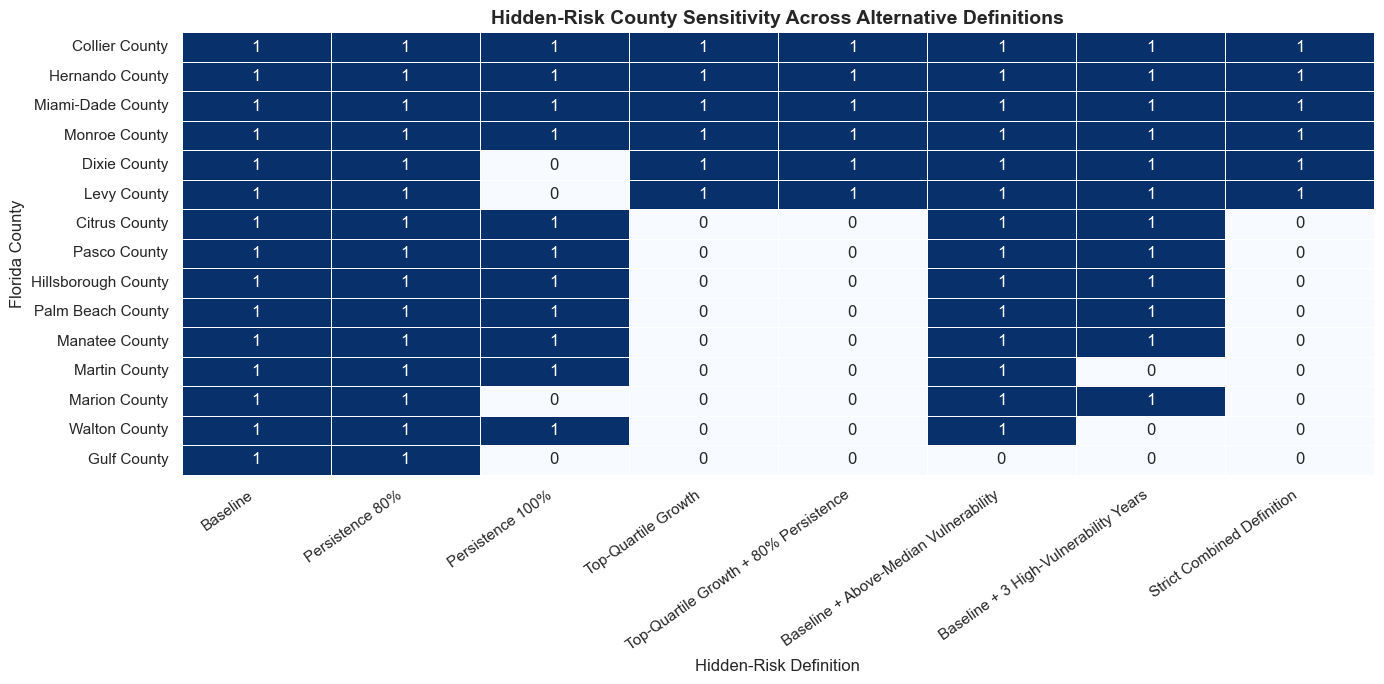

Hidden-risk sensitivity outputs saved successfully.
Figure saved to: ..\results\figures\vulnerability_clustering\hidden_risk_threshold_sensitivity.png


In [27]:
# ==================================================
# Hidden-Risk Threshold Sensitivity Analysis
# ==================================================

# Additional statewide threshold
median_vulnerability_threshold = (
    hidden_risk_assessment[
        "recent_avg_vulnerability_score"
    ]
    .median()
)

# ==================================================
# Define Alternative Hidden-Risk Scenarios
# ==================================================

sensitivity_scenarios = {
    "Baseline": {
        "growth_threshold": median_growth_threshold,
        "persistence_threshold": 60,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 0
    },

    "Persistence 80%": {
        "growth_threshold": median_growth_threshold,
        "persistence_threshold": 80,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 0
    },

    "Persistence 100%": {
        "growth_threshold": median_growth_threshold,
        "persistence_threshold": 100,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 0
    },

    "Top-Quartile Growth": {
        "growth_threshold": top_quartile_growth_threshold,
        "persistence_threshold": 60,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 0
    },

    "Top-Quartile Growth + 80% Persistence": {
        "growth_threshold": top_quartile_growth_threshold,
        "persistence_threshold": 80,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 0
    },

    "Baseline + Above-Median Vulnerability": {
        "growth_threshold": median_growth_threshold,
        "persistence_threshold": 60,
        "require_median_vulnerability": True,
        "minimum_high_vulnerability_years": 0
    },

    "Baseline + 3 High-Vulnerability Years": {
        "growth_threshold": median_growth_threshold,
        "persistence_threshold": 60,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 3
    },

    "Strict Combined Definition": {
        "growth_threshold": top_quartile_growth_threshold,
        "persistence_threshold": 80,
        "require_median_vulnerability": True,
        "minimum_high_vulnerability_years": 3
    }
}

# ==================================================
# Apply Every Sensitivity Scenario
# ==================================================

sensitivity_selection_matrix = (
    hidden_risk_assessment[
        [
            "STCOFIPS",
            "RegionName"
        ]
    ]
    .copy()
)

scenario_summary_rows = []

for scenario_number, (
    scenario_name,
    criteria
) in enumerate(
    sensitivity_scenarios.items(),
    start=1
):

    scenario_flag = (
        hidden_risk_assessment[
            "current_or_dominant_risk_profile"
        ]
        &
        (
            hidden_risk_assessment[
                "risk_cluster_share_pct"
            ]
            >= criteria["persistence_threshold"]
        )
        &
        (
            hidden_risk_assessment[
                "recent_avg_annual_growth_pct"
            ]
            >= criteria["growth_threshold"]
        )
    )

    if criteria[
        "require_median_vulnerability"
    ]:
        scenario_flag = (
            scenario_flag
            &
            (
                hidden_risk_assessment[
                    "recent_avg_vulnerability_score"
                ]
                >= median_vulnerability_threshold
            )
        )

    if (
        criteria[
            "minimum_high_vulnerability_years"
        ]
        > 0
    ):
        scenario_flag = (
            scenario_flag
            &
            (
                hidden_risk_assessment[
                    "high_vulnerability_years"
                ]
                >= criteria[
                    "minimum_high_vulnerability_years"
                ]
            )
        )

    scenario_column = (
        f"scenario_{scenario_number}"
    )

    sensitivity_selection_matrix[
        scenario_column
    ] = scenario_flag.astype(int)

    selected_counties = (
        hidden_risk_assessment.loc[
            scenario_flag,
            "RegionName"
        ]
        .sort_values()
        .tolist()
    )

    scenario_summary_rows.append({
        "scenario_number":
            scenario_number,
        "scenario_name":
            scenario_name,
        "growth_threshold_pct":
            criteria["growth_threshold"],
        "persistence_threshold_pct":
            criteria["persistence_threshold"],
        "requires_above_median_vulnerability":
            criteria[
                "require_median_vulnerability"
            ],
        "minimum_high_vulnerability_years":
            criteria[
                "minimum_high_vulnerability_years"
            ],
        "counties_identified":
            int(scenario_flag.sum()),
        "selected_counties":
            "; ".join(selected_counties)
    })

hidden_risk_sensitivity_summary = pd.DataFrame(
    scenario_summary_rows
)

# ==================================================
# Create County-Level Sensitivity Summary
# ==================================================

scenario_columns = [
    column
    for column in sensitivity_selection_matrix.columns
    if column.startswith("scenario_")
]

sensitivity_selection_matrix[
    "scenarios_selected"
] = (
    sensitivity_selection_matrix[
        scenario_columns
    ]
    .sum(axis=1)
)

number_of_scenarios = len(
    scenario_columns
)

sensitivity_selection_matrix[
    "selection_rate_pct"
] = (
    sensitivity_selection_matrix[
        "scenarios_selected"
    ]
    / number_of_scenarios
    * 100
)

sensitivity_selection_matrix[
    "selected_in_all_scenarios"
] = (
    sensitivity_selection_matrix[
        "scenarios_selected"
    ]
    == number_of_scenarios
)

sensitivity_selection_matrix[
    "selected_in_majority_of_scenarios"
] = (
    sensitivity_selection_matrix[
        "scenarios_selected"
    ]
    >= np.ceil(
        number_of_scenarios / 2
    )
)

county_sensitivity_summary = (
    hidden_risk_assessment[
        [
            "STCOFIPS",
            "RegionName",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
            "risk_cluster_share_pct",
            "high_vulnerability_years",
            "latest_cluster_name",
            "dominant_recent_cluster_name"
        ]
    ]
    .merge(
        sensitivity_selection_matrix[
            [
                "STCOFIPS",
                "scenarios_selected",
                "selection_rate_pct",
                "selected_in_all_scenarios",
                "selected_in_majority_of_scenarios"
            ]
        ],
        on="STCOFIPS",
        how="left"
    )
    .sort_values(
        [
            "scenarios_selected",
            "risk_cluster_share_pct",
            "recent_avg_annual_growth_pct"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
)

# Retain counties identified in at least one scenario
sensitivity_counties = (
    county_sensitivity_summary[
        county_sensitivity_summary[
            "scenarios_selected"
        ] > 0
    ]
    .reset_index(drop=True)
)

# ==================================================
# Rename Scenario Columns for Presentation
# ==================================================

scenario_column_names = {
    f"scenario_{scenario_number}":
        scenario_name
    for scenario_number, scenario_name
    in enumerate(
        sensitivity_scenarios.keys(),
        start=1
    )
}

presentation_selection_matrix = (
    sensitivity_selection_matrix
    .rename(
        columns=scenario_column_names
    )
)

# ==================================================
# Display Results
# ==================================================

print(
    "Hidden-risk threshold sensitivity analysis completed."
)

print(
    f"Median recent vulnerability threshold: "
    f"{median_vulnerability_threshold:.4f}"
)

print(
    f"Scenarios tested: "
    f"{number_of_scenarios}"
)

print("\nSensitivity scenario summary")
display(
    hidden_risk_sensitivity_summary[
        [
            "scenario_name",
            "growth_threshold_pct",
            "persistence_threshold_pct",
            "requires_above_median_vulnerability",
            "minimum_high_vulnerability_years",
            "counties_identified"
        ]
    ].round(4)
)

print(
    "Counties identified in at least one scenario"
)
display(
    sensitivity_counties[
        [
            "RegionName",
            "scenarios_selected",
            "selection_rate_pct",
            "risk_cluster_share_pct",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
            "high_vulnerability_years",
            "dominant_recent_cluster_name"
        ]
    ].round(4)
)

print("Counties identified in every scenario")
display(
    sensitivity_counties[
        sensitivity_counties[
            "selected_in_all_scenarios"
        ]
    ][
        [
            "RegionName",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
            "risk_cluster_share_pct",
            "high_vulnerability_years"
        ]
    ].round(4)
)

# ==================================================
# Visualize Scenario Consistency
# ==================================================

plot_selection_matrix = (
    presentation_selection_matrix[
        presentation_selection_matrix[
            "scenarios_selected"
        ] > 0
    ]
    .set_index("RegionName")[
        list(
            sensitivity_scenarios.keys()
        )
    ]
)

# Sort counties by number of scenarios selected
plot_selection_matrix = (
    plot_selection_matrix
    .assign(
        total_selected=lambda data:
            data.sum(axis=1)
    )
    .sort_values(
        "total_selected",
        ascending=False
    )
    .drop(
        columns="total_selected"
    )
)

plt.figure(
    figsize=(
        14,
        max(
            7,
            len(plot_selection_matrix) * 0.45
        )
    )
)

sns.heatmap(
    plot_selection_matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Hidden-Risk County Sensitivity Across Alternative Definitions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Hidden-Risk Definition")
plt.ylabel("Florida County")
plt.xticks(
    rotation=35,
    ha="right"
)
plt.yticks(rotation=0)

plt.tight_layout()

sensitivity_figure_path = (
    RESULTS_FIGURES
    / "hidden_risk_threshold_sensitivity.png"
)

plt.savefig(
    sensitivity_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==================================================
# Save Sensitivity Outputs
# ==================================================

hidden_risk_sensitivity_summary.to_csv(
    RESULTS_TABLES
    / "hidden_risk_sensitivity_scenarios.csv",
    index=False
)

presentation_selection_matrix.to_csv(
    RESULTS_TABLES
    / "hidden_risk_sensitivity_selection_matrix.csv",
    index=False
)

county_sensitivity_summary.to_csv(
    RESULTS_TABLES
    / "hidden_risk_sensitivity_county_summary.csv",
    index=False
)

print(
    "Hidden-risk sensitivity outputs saved successfully."
)

print(
    f"Figure saved to: "
    f"{sensitivity_figure_path}"
)

### Interpretation

The threshold-sensitivity analysis shows that the hidden-risk finding is not dependent on a single researcher-selected definition. The baseline criteria identified 15 counties with above-median recent housing growth and persistent membership in the two risk-oriented profiles.

Increasing the persistence requirement from 60% to 80% did not remove any counties, indicating that all baseline cases belonged to a risk-oriented profile in at least four of the five recent years. Requiring 100% persistence reduced the group to 11 counties.

The largest reduction resulted from replacing the median housing-growth threshold with the upper-quartile threshold. This produced six priority hidden-risk counties: Hernando, Collier, Monroe, Miami-Dade, Dixie, and Levy. The same six counties remained under the strict combined definition, which additionally required above-median vulnerability and at least three High-vulnerability years.

Four counties—Hernando, Collier, Monroe, and Miami-Dade—were identified in all eight sensitivity scenarios. These counties represent the most robust hidden-risk cases because they combine strong recent housing growth, continuous risk-profile membership, elevated overall vulnerability, and repeated High-vulnerability classification.

The sensitivity results therefore support a tiered interpretation: 15 counties form the broader hidden-risk group, six represent priority hidden-risk counties, and four constitute the most robust core cases.

## 22. Visualize Hidden-Risk Counties

Plot recent housing growth against average vulnerability to show where strong market performance overlaps with persistent risk-heavy cluster membership.

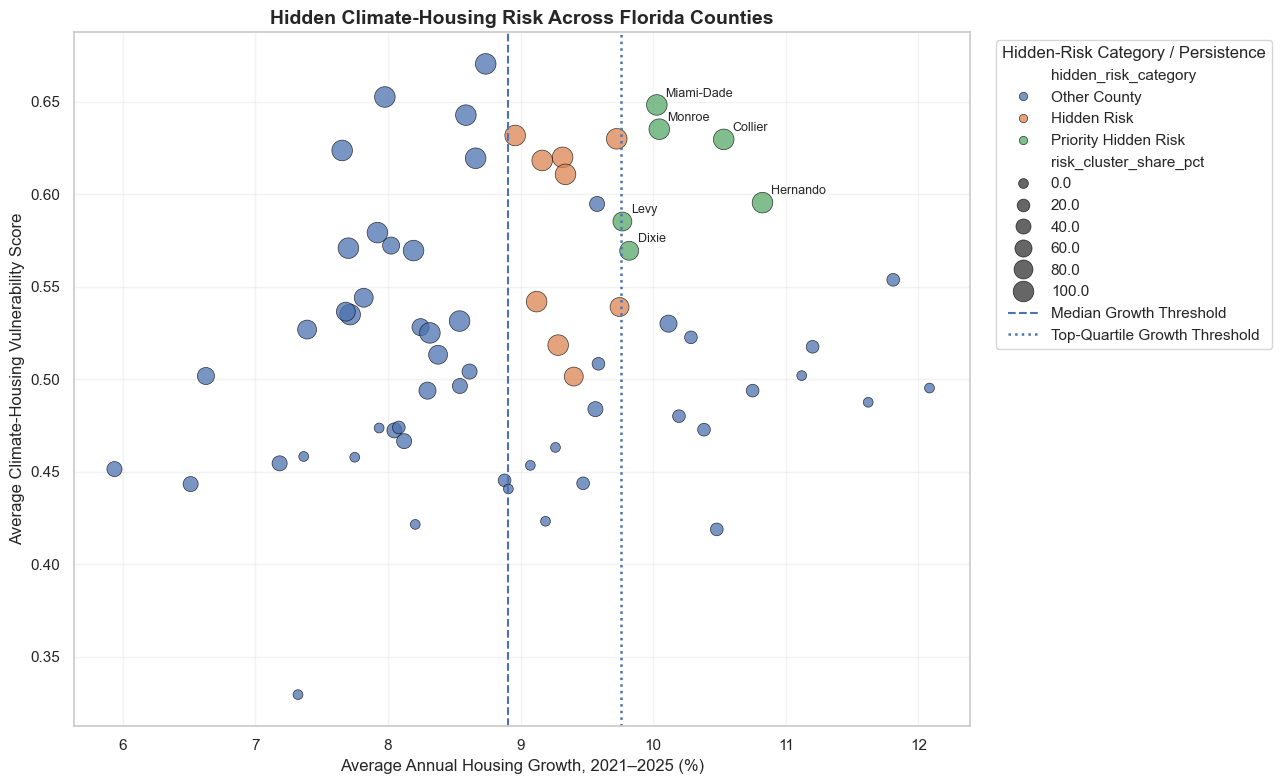

Hidden-risk county figure saved to: ..\results\figures\vulnerability_clustering\hidden_risk_county_scatterplot.png


In [28]:
# ==================================================
# Step 22: Visualize Hidden-Risk Counties
# ==================================================

hidden_risk_category_order = [
    "Other County",
    "Hidden Risk",
    "Priority Hidden Risk"
]

plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=hidden_risk_assessment,
    x="recent_avg_annual_growth_pct",
    y="recent_avg_vulnerability_score",
    hue="hidden_risk_category",
    hue_order=hidden_risk_category_order,
    size="risk_cluster_share_pct",
    sizes=(50, 220),
    alpha=0.75,
    edgecolor="black",
    linewidth=0.5
)

# ==================================================
# Growth Thresholds
# ==================================================

plt.axvline(
    median_growth_threshold,
    linestyle="--",
    linewidth=1.5,
    label="Median Growth Threshold"
)

plt.axvline(
    top_quartile_growth_threshold,
    linestyle=":",
    linewidth=1.8,
    label="Top-Quartile Growth Threshold"
)

# ==================================================
# Label Priority Hidden-Risk Counties
# ==================================================

priority_counties = hidden_risk_assessment[
    hidden_risk_assessment["priority_hidden_risk_flag"]
].copy()

for _, row in priority_counties.iterrows():
    county_label = row["RegionName"].replace(
        " County",
        ""
    )

    plt.annotate(
        county_label,
        (
            row["recent_avg_annual_growth_pct"],
            row["recent_avg_vulnerability_score"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.title(
    "Hidden Climate-Housing Risk Across Florida Counties",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    f"Average Annual Housing Growth, "
    f"{recent_start_year}–{latest_year} (%)"
)

plt.ylabel(
    "Average Climate-Housing Vulnerability Score"
)

plt.legend(
    title="Hidden-Risk Category / Persistence",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.25)
plt.tight_layout()

figure_path = (
    RESULTS_FIGURES
    / "hidden_risk_county_scatterplot.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Hidden-risk county figure saved to: "
    f"{figure_path}"
)

## 23. Save Final Clustering Outputs

Save the final cluster assignments, profiles, evaluation tables, and county-level hidden-risk results for later analysis and reporting.

In [29]:
# ==================================================
# Step 23: Save Final Clustering Outputs
# ==================================================

import joblib

# ==================================================
# Save Final County-Year Cluster Assignments
# ==================================================

clustered_output_path = (
    RESULTS_TABLES
    / "county_year_vulnerability_clusters.csv"
)

clustered_data.to_csv(
    clustered_output_path,
    index=False
)

# ==================================================
# Save Clustering Evaluation Tables
# ==================================================

cluster_selection_table.to_csv(
    RESULTS_TABLES / "kmeans_cluster_selection_results.csv",
    index=False
)

algorithm_comparison_table.to_csv(
    RESULTS_TABLES / "clustering_algorithm_comparison.csv",
    index=False
)

cluster_stability_table.to_csv(
    RESULTS_TABLES / "cluster_stability_results.csv",
    index=False
)

correlation_matrix.to_csv(
    RESULTS_TABLES / "clustering_feature_correlations.csv"
)

clustering_summary.to_csv(
    RESULTS_TABLES / "clustering_feature_summary.csv"
)

# ==================================================
# Save Final Cluster Profile Tables
# ==================================================

final_cluster_profiles.to_csv(
    RESULTS_TABLES / "standardized_cluster_profiles.csv"
)

final_cluster_profile_table.to_csv(
    RESULTS_TABLES / "final_cluster_profiles.csv"
)

cluster_name_table.to_csv(
    RESULTS_TABLES / "cluster_name_mapping.csv",
    index=False
)

housing_market_profile_table.to_csv(
    RESULTS_TABLES / "cluster_housing_market_profiles.csv"
)

cluster_class_counts.to_csv(
    RESULTS_TABLES / "cluster_vulnerability_class_counts.csv"
)

cluster_class_percentages.to_csv(
    RESULTS_TABLES / "cluster_vulnerability_class_percentages.csv"
)

# ==================================================
# Save PCA Results
# ==================================================

explained_variance_table.to_csv(
    RESULTS_TABLES / "pca_explained_variance.csv",
    index=False
)

pca_centers_table.to_csv(
    RESULTS_TABLES / "pca_cluster_centers.csv",
    index=False
)

# ==================================================
# Save County-Level Results
# ==================================================

county_cluster_membership.to_csv(
    RESULTS_TABLES / "county_cluster_membership.csv",
    index=False
)

hidden_risk_assessment.to_csv(
    RESULTS_TABLES / "county_hidden_risk_assessment.csv",
    index=False
)

hidden_risk_counties.to_csv(
    RESULTS_TABLES / "hidden_risk_counties.csv",
    index=False
)

# ==================================================
# Save Fitted Objects
# ==================================================

joblib.dump(
    scaler,
    RESULTS_MODELS / "clustering_standard_scaler.joblib"
)

joblib.dump(
    final_kmeans_model,
    RESULTS_MODELS / "final_kmeans_model.joblib"
)

joblib.dump(
    pca,
    RESULTS_MODELS / "clustering_pca_model.joblib"
)

# ==================================================
# Save Notebook Summary
# ==================================================

clustering_output_summary = pd.DataFrame({
    "item": [
        "County-year observations",
        "Florida counties",
        "Study period",
        "Clustering features",
        "Final number of clusters",
        "Final clustering algorithm",
        "Hidden-risk counties",
        "Priority hidden-risk counties"
    ],
    "value": [
        len(clustered_data),
        clustered_data["STCOFIPS"].nunique(),
        f"{clustered_data['Year'].min()}–{clustered_data['Year'].max()}",
        len(CLUSTERING_FEATURES),
        FINAL_N_CLUSTERS,
        "K-Means",
        len(hidden_risk_counties),
        int(hidden_risk_counties["priority_hidden_risk_flag"].sum())
    ]
})

clustering_output_summary.to_csv(
    RESULTS_TABLES / "clustering_output_summary.csv",
    index=False
)

print("Final clustering outputs saved successfully.")
print(f"Clustered dataset: {clustered_output_path}")
print(f"Tables folder: {RESULTS_TABLES}")
print(f"Figures folder: {RESULTS_FIGURES}")
print(f"Models folder: {RESULTS_MODELS}")

display(clustering_output_summary)

Final clustering outputs saved successfully.
Clustered dataset: ..\results\tables\vulnerability_clustering\county_year_vulnerability_clusters.csv
Tables folder: ..\results\tables\vulnerability_clustering
Figures folder: ..\results\figures\vulnerability_clustering
Models folder: ..\results\models\vulnerability_clustering


,item,value
0,County-year observations,1000
1,Florida counties,67
2,Study period,2011–2025
3,Clustering features,7
4,Final number of clusters,4
5,Final clustering algorithm,K-Means
6,Hidden-risk counties,15
7,Priority hidden-risk counties,6


## 24. Final Interpretation and Key Findings

### Purpose of the Unsupervised Analysis

The supervised classification analysis categorized county-year observations into Low, Medium, and High climate-housing vulnerability. However, an overall vulnerability class does not explain the particular combination of conditions producing that vulnerability.

Unsupervised clustering was therefore used to identify recurring vulnerability profiles based on seven theoretically motivated dimensions:

- affordability stress;
- climate exposure;
- disaster history;
- socioeconomic vulnerability;
- resilience-related stress;
- insurance-loss stress;
- spatial spillover pressure.

Direct housing-market outcomes, including annual price growth, price level, volatility, and the housing-pressure score, were excluded from cluster formation and used afterwards to interpret the resulting profiles.

The clustering analysis therefore complements the supervised model by identifying different forms or pathways of vulnerability rather than only different levels of vulnerability.

---

### Selection of the Four-Profile Solution

Candidate K-Means solutions were evaluated using silhouette score, Calinski–Harabasz score, Davies–Bouldin score, cluster sizes, stability, and substantive interpretability.

The two-cluster solution achieved the highest silhouette score of 0.2477, compared with 0.1865 for four clusters. However, the two-cluster model primarily separated observations into broad lower-stress and higher-stress groups and did not reveal the multidimensional vulnerability pathways required for the research objective.

The four-cluster solution was retained because it distinguished four substantively meaningful profiles while maintaining usable cluster sizes:

- Lower-Stress Resilient Profile: 171 observations, or 17.1%;
- Disaster-Loss Growth Pressure: 191 observations, or 19.1%;
- High-Exposure Latent Risk: 284 observations, or 28.4%;
- Socioeconomic Resilience Stress: 354 observations, or 35.4%.

K-Means also performed better than Gaussian Mixture and Agglomerative Clustering for the selected four-profile solution. The final result is therefore interpreted as an exploratory vulnerability typology rather than evidence that Florida county-year observations form four perfectly isolated natural groups.

---

### Profile 1: Lower-Stress Resilient Profile

The Lower-Stress Resilient Profile is primarily characterized by lower socioeconomic vulnerability and stronger resilience capacity. It also has relatively low disaster, affordability, and spatial stress compared with the other profiles.

This profile had:

- average annual housing growth of approximately 4.21%;
- average annual housing price of approximately $243,656;
- average vulnerability score of approximately 0.399;
- 69.01% Low-vulnerability observations;
- only 2.34% High-vulnerability observations.

Representative county-year observations included Clay County in 2019, Sumter County in 2019, Nassau County in 2014, Lake County in 2019, and Seminole County in 2019.

This profile provides a useful comparison group showing that stronger resilience and lower social sensitivity can reduce vulnerability even when counties are not completely free from climate or housing-market pressure.

---

### Profile 2: Disaster-Loss Growth Pressure

The Disaster-Loss Growth Pressure profile combines the highest disaster-history burden, insurance-loss stress, affordability pressure, and housing-market pressure.

It had:

- average annual housing growth of approximately 8.95%, the highest of the four profiles;
- average annual housing price of approximately $352,240, also the highest;
- average vulnerability score of approximately 0.577;
- 75.39% High-vulnerability observations.

Representative observations included Flagler County in 2019, Franklin County in 2023, Martin County in 2017, Volusia County in 2019, and Bay County in 2023. Persistent recent examples included Bay, Manatee, Walton, Monroe, and Hillsborough counties.

Not every individual observation in this profile experienced positive annual price growth. The name refers to the cluster’s overall housing-market pattern, not a requirement that every county-year grow strongly.

This profile provides the clearest evidence supporting the project’s main argument: strong housing markets can coexist with repeated disasters, large insurance losses, affordability pressure, and elevated climate-housing vulnerability.

---

### Profile 3: High-Exposure Latent Risk

The High-Exposure Latent Risk profile is characterized by the highest structural climate exposure, elevated insurance-loss stress, and spatial pressure, but lower realized disaster-history scores than the Disaster-Loss Growth Pressure profile.

It had:

- average annual housing growth of approximately 7.05%;
- average annual housing price of approximately $203,770;
- average vulnerability score of approximately 0.523;
- 53.87% High-vulnerability observations.

Representative observations included Bay County in 2015, Hillsborough County in 2018, Manatee County in 2013, Palm Beach County in 2013, and Flagler County in 2014.

The term latent indicates that vulnerability is embedded in structural exposure and financial-loss conditions even when recorded disaster history is not yet as high as in the realized disaster-loss profile.

This was also the least persistent and least robust profile. Only four counties had High-Exposure Latent Risk as their dominant recent profile, and none remained in it throughout all five recent years. It should therefore be interpreted as a more transitional county-year state rather than a permanent county category.

---

### Profile 4: Socioeconomic Resilience Stress

The Socioeconomic Resilience Stress profile represents a distinct vulnerability pathway driven primarily by elevated socioeconomic sensitivity and weaker resilience capacity rather than by the highest physical exposure or insurance losses.

It had:

- average annual housing growth of approximately 5.19%;
- average annual housing price of approximately $138,268, the lowest of the four profiles;
- average vulnerability score of approximately 0.429;
- 53.67% Low-vulnerability observations;
- 37.29% Medium-vulnerability observations;
- 9.04% High-vulnerability observations.

Representative observations included Hardee County in 2019, Lafayette County in 2018, Columbia County in 2016, Highlands County in 2019, and Madison County in 2019. Persistent recent examples included Jackson, Calhoun, Gadsden, Okeechobee, and Hamilton counties.

This profile demonstrates that lower climate exposure does not necessarily mean an absence of vulnerability. Counties may still have limited capacity to absorb future shocks because of household-level socioeconomic stress and reduced community resilience.

---

### Relationship Between Clusters and Vulnerability Classes

The clustering results show that the Low, Medium, and High vulnerability classes do not represent uniform county types.

Medium-vulnerability observations appeared across all four profiles:

- 28.65% of Lower-Stress Resilient observations;
- 24.08% of Disaster-Loss Growth Pressure observations;
- 37.32% of High-Exposure Latent Risk observations;
- 37.29% of Socioeconomic Resilience Stress observations.

This means that two counties with the same Medium vulnerability label may have very different underlying conditions. One may be primarily affected by climate exposure, another by socioeconomic vulnerability, and another by realized disaster and insurance-loss pressure.

The vulnerability class therefore summarizes overall intensity, while the clusters identify the composition of that vulnerability.

---

### Temporal Evolution of the Profiles

Cluster membership had a statistically significant and moderate relationship with year, with a bias-corrected Cramér’s V of 0.3595.

The Disaster-Loss Growth Pressure profile increased substantially over time:

- 0.00% of observations during 2011–2015;
- 13.43% during 2016–2020;
- 43.58% during 2021–2025.

It accounted for 70.15% of observations in 2022 and 74.63% in 2024.

In contrast, High-Exposure Latent Risk declined from 38.79% of observations during 2011–2015 to 11.94% during 2021–2025.

This pattern suggests that some counties may move from an exposure-oriented state toward a realized disaster-loss state as disasters, insurance losses, affordability pressure, and related stresses accumulate.

The Lower-Stress Resilient Profile remained relatively stable across the three five-year periods, while Socioeconomic Resilience Stress remained present throughout the full study period.

The profiles should therefore be interpreted as recurring county-year vulnerability states rather than fixed county identities.

---

### Robustness and Stability Findings

The recent county-level robustness analysis averaged the seven clustering dimensions across 2021–2025, producing one observation for each of Florida’s 67 counties.

The county-level comparison produced:

- exact profile agreement of 64.18%;
- Adjusted Rand Index of 0.444.

The Disaster-Loss Growth Pressure and Socioeconomic Resilience Stress profile shapes were reproduced most clearly. High-Exposure Latent Risk was less strongly reproduced after temporal averaging, supporting its interpretation as a more transitional profile.

County-level bootstrap testing also showed moderate overall sample stability:

- mean full-sample ARI: 0.5338;
- mean out-of-bag ARI: 0.5251;
- mean full-sample assignment agreement: 69.24%;
- mean out-of-bag assignment agreement: 68.27%.

Profile-level out-of-bag assignment stability was:

- Disaster-Loss Growth Pressure: 77.93%;
- Socioeconomic Resilience Stress: 77.80%;
- Lower-Stress Resilient: 60.64%;
- High-Exposure Latent Risk: 54.09%.

These findings indicate that the four-profile solution is informative and reasonably reproducible, but its boundaries are not rigid. Disaster-Loss Growth Pressure and Socioeconomic Resilience Stress are the most stable profiles, while High-Exposure Latent Risk is more sensitive to temporal aggregation and changes in the county sample.

---

### PCA Interpretation

The first two principal components explained 54.92% of the total variation:

- PC1 explained 37.83%;
- PC2 explained 17.09%.

PC1 was driven most strongly by insurance-loss stress, affordability stress, climate exposure, and disaster history. It represents a physical, financial, and housing-pressure dimension.

PC2 was driven primarily by resilience-related stress and socioeconomic vulnerability. It represents a socioeconomic vulnerability and resilience-stress dimension.

The Disaster-Loss Growth Pressure centroid was positioned furthest along the physical and financial pressure axis. The Lower-Stress Resilient Profile was distinguished by its low position on the socioeconomic and resilience-stress axis, while Socioeconomic Resilience Stress occupied the opposite side of the physical-loss dimension.

The confidence ellipses overlap, indicating that vulnerability exists on a continuum. However, the separated cluster centroids confirm that the profiles represent different average combinations of exposure, loss, social sensitivity, affordability, and resilience.

---

### Hidden-Risk County Findings

The baseline hidden-risk definition identified counties with:

- above-median average housing growth during 2021–2025;
- membership in a risk-oriented profile during at least 60% of the recent period.

This identified 15 hidden-risk counties.

Using upper-quartile growth produced six priority hidden-risk counties:

- Hernando;
- Collier;
- Monroe;
- Miami-Dade;
- Dixie;
- Levy.

The threshold-sensitivity analysis tested eight alternative definitions based on growth, persistence, overall vulnerability, and repeated High-vulnerability classification.

Four counties were selected in every scenario:

- Hernando County;
- Collier County;
- Monroe County;
- Miami-Dade County.

These represent the most robust hidden-risk cases because they combine:

- strong recent housing growth;
- continuous risk-oriented profile membership;
- elevated average vulnerability;
- repeated High-vulnerability years.

The sensitivity analysis therefore supports a tiered interpretation:

- 15 broader hidden-risk counties;
- 6 priority hidden-risk counties;
- 4 core counties supported by every tested definition.

---

### Main Contribution of the Clustering Analysis

The clustering analysis shows that climate-housing vulnerability is not one uniform condition.

Florida county-year observations experience vulnerability through different combinations of:

- structural climate exposure;
- realized disaster losses;
- insurance-related financial stress;
- housing affordability pressure;
- socioeconomic sensitivity;
- resilience capacity;
- spatial housing-market conditions.

The analysis also shows that high housing growth does not necessarily indicate low vulnerability. The Disaster-Loss Growth Pressure profile had the highest average housing growth and housing prices despite also carrying the greatest disaster and insurance-loss burden.

The unsupervised results therefore strengthen the central argument of the MRP:

> Strong housing-market performance can coexist with substantial underlying climate, financial, socioeconomic, and resilience-related vulnerability.

---

### Limitations

The clustering results should be interpreted with several limitations:

- The four-cluster solution did not have the highest silhouette score and was selected partly for substantive interpretability.
- County-year observations from the same county are related and should not be treated as completely independent.
- Some clustering dimensions include cumulative or recent-history measures, creating a temporal component in cluster membership.
- Bootstrap stability was moderate rather than strong.
- High-Exposure Latent Risk was less stable than the other profiles.
- PCA retained only 54.92% of the original seven-dimensional variation.
- Cluster assignments describe similarities in observed vulnerability conditions and do not establish causal relationships.
- The profiles should be treated as exploratory county-year vulnerability states rather than permanent or perfectly separated county categories.

Despite these limitations, the convergence of cluster profiles, housing-market comparisons, temporal patterns, county examples, robustness tests, and hidden-risk sensitivity results provides meaningful support for the use of unsupervised learning in the wider climate-housing vulnerability framework.